# Map of axonal length

In [2]:
import numpy as np
import pandas as pd
n_sims = 5


files = [f"GNA_map_vsLength/2D_GNAmap_square_SW_rho71_s0.70_sim{i}_chunk0.txt" for i in range(n_sims)]

# files = [
#     "Gini_things/GNAmap_circle_SW_rho60_l0.30_sim0.txt",
#     "Gini_things/GNAmap_circle_SW_rho60_l0.30_sim1.txt",
#     "Gini_things/GNAmap_circle_SW_rho60_l0.30_sim2.txt"
# ]

dfs = []

for file in files:
    df = pd.read_csv(file, sep=r"\s+")
    dfs.append(df)
    print(f"Archivo {file} cargado con {len(df)} filas.")

data_all = pd.concat(dfs, ignore_index=True)

data_mean = (
    data_all
    .groupby(["axonal_length", "MAX_EXC_WEIGHT"], as_index=False)
    [["mean_peaks_height", "std_peaks_height", "fano_factor", "GC_fraction", "mean_degree"]]
    .mean()
)

output_file = "GNA_map_vsLength/2D_GNAmap_square_SW_rho71_s0.70_l1.00_mean.txt"

data_mean.to_csv(
    output_file,
    sep="\t",
    index=False,
    float_format="%.6f"
)

print(data_mean.head())
print(f"Guardado en: {output_file}")

Archivo GNA_map_vsLength/2D_GNAmap_square_SW_rho71_s0.70_sim0_chunk0.txt cargado con 2500 filas.
Archivo GNA_map_vsLength/2D_GNAmap_square_SW_rho71_s0.70_sim1_chunk0.txt cargado con 2500 filas.
Archivo GNA_map_vsLength/2D_GNAmap_square_SW_rho71_s0.70_sim2_chunk0.txt cargado con 2500 filas.
Archivo GNA_map_vsLength/2D_GNAmap_square_SW_rho71_s0.70_sim3_chunk0.txt cargado con 2500 filas.
Archivo GNA_map_vsLength/2D_GNAmap_square_SW_rho71_s0.70_sim4_chunk0.txt cargado con 2500 filas.
   axonal_length  MAX_EXC_WEIGHT  mean_peaks_height  std_peaks_height  \
0            0.1            2.00           0.088167          0.002723   
1            0.1            2.57           0.088167          0.002723   
2            0.1            3.14           0.088097          0.002662   
3            0.1            3.71           0.110326          0.003896   
4            0.1            4.29           0.110431          0.003993   

   fano_factor  GC_fraction  mean_degree  
0     0.000327     0.066354      

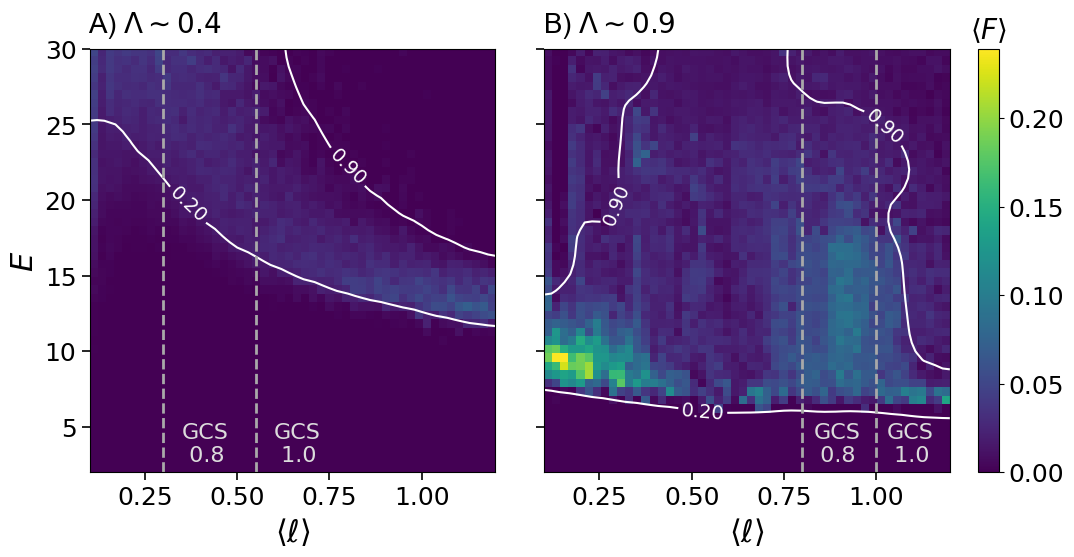

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from pathlib import Path
from matplotlib.pylab import seed
import numpy as np
import matplotlib.pyplot as plt
from pypalettes import load_cmap 
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
from numba import njit

# =========================
# OPCIONES
# =========================

# heatmap_value = "GC_fraction"        # "fano_factor" o "mean_peaks_height"
# heatmap_value = "mean_degree"        # "fano_factor" o "mean_peaks_height"
heatmap_value = "fano_factor"        # "fano_factor" o "mean_peaks_height"
# heatmap_value = "mean_peaks_height"  # "fano_factor" o "mean_peaks_height"
contour_value = "mean_peaks_height"  # "fano_factor" o "mean_peaks_height"

smooth_sigma = 2

# Si lo dejas en None, calcula niveles automáticamente
contour_levels = None
contour_levels = [0.2, 0.9]

labels = {
    "fano_factor": r"$F = \sigma^2/\mu$",
    "mean_peaks_height": r"$\langle GNA \rangle$"
}

# =========================
# CARGA DATOS
# =========================

mapdata_square120 = pd.read_csv("GNA_map_vsLength/2D_GNAmap_square_SW_rho71_s0.03_l1.00_mean.txt", sep="\t")
mapdata_square030 = pd.read_csv("GNA_map_vsLength/2D_GNAmap_square_SW_rho71_s0.70_l1.00_mean.txt", sep="\t")
# mapdata_square030 = pd.read_csv("GNA_map_vsLength/3D_GNAmap_cube_SW_rho1400_s0.03_sim0.txt", sep="\t")
# mapdata_square120 = pd.read_csv("GNA_map_vsLength/3D_GNAmap_cube_SW_rho1400_s0.45_sim0.txt", sep="\t")

def make_grid(df, value):
    pivot = df.pivot(
        index="MAX_EXC_WEIGHT",
        columns="axonal_length",
        values=value
    ).sort_index()

    x = pivot.columns.to_numpy(dtype=float)
    y = pivot.index.to_numpy(dtype=float)
    Z = pivot.to_numpy(dtype=float)

    return x, y, Z


# =========================
# MATRICES
# =========================

x_sq, y_sq, Z_sq_heat = make_grid(mapdata_square030, heatmap_value)
x_ci, y_ci, Z_ci_heat = make_grid(mapdata_square120, heatmap_value)

_, _, Z_sq_contour = make_grid(mapdata_square030, contour_value)
_, _, Z_ci_contour = make_grid(mapdata_square120, contour_value)

Z_sq_contour_smooth = gaussian_filter(Z_sq_contour, sigma=smooth_sigma)
Z_ci_contour_smooth = gaussian_filter(Z_ci_contour, sigma=smooth_sigma)

# Escala común del mapa de color
vmin = min(np.nanmin(Z_sq_heat), np.nanmin(Z_ci_heat))
vmax = max(np.nanmax(Z_sq_heat), np.nanmax(Z_ci_heat))

# Niveles automáticos para los contornos
if contour_levels is None:
    cmin = min(np.nanmin(Z_sq_contour_smooth), np.nanmin(Z_ci_contour_smooth))
    cmax = max(np.nanmax(Z_sq_contour_smooth), np.nanmax(Z_ci_contour_smooth))
    contour_levels = np.linspace(cmin, cmax, 6)[1:-1]


# =========================
# FIGURA
# =========================

fig, axs = plt.subplots(
    1, 2,
    figsize=(12, 5.5),
    sharex=True,
    sharey=True,
    gridspec_kw={"wspace": 0.12}
)

# Square
im0 = axs[0].imshow(
    Z_sq_heat,
    origin="lower",
    aspect="auto",
    extent=[x_sq.min(), x_sq.max(), y_sq.min(), y_sq.max()],
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest"
)

cs1 = axs[0].contour(
    x_sq,
    y_sq,
    Z_sq_contour_smooth,
    levels=contour_levels,
    colors="white",
    linewidths=1.5,
    linestyles="-"
)

# Circle
im1 = axs[1].imshow(
    Z_ci_heat,
    origin="lower",
    aspect="auto",
    extent=[x_ci.min(), x_ci.max(), y_ci.min(), y_ci.max()],
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest"
)

cs2 = axs[1].contour(
    x_ci,
    y_ci,
    Z_ci_contour_smooth,
    levels=contour_levels,
    colors="white",
    linewidths=1.5,
    linestyles="-"
)

axs[0].clabel(cs1, inline=True, fontsize=14, fmt="%.2f")
axs[1].clabel(cs2, inline=True, fontsize=14, fmt="%.2f")

# Títulos
axs[0].text(
    0.16, 1.02, "A) " + r"$\Lambda\sim0.4$",
    transform=axs[0].transAxes,
    ha="center",
    va="bottom",
    fontsize=20,
    font="Arial",
    color = "black",
    bbox=dict(facecolor="white", alpha=0.0, edgecolor="none", pad=6)
)

axs[1].text(
    0.16, 1.02, "B) " + r"$\Lambda\sim0.9$",
    transform=axs[1].transAxes,
    ha="center",
    va="bottom",
    fontsize=20,
    font="Arial",
    color = "black",
    bbox=dict(facecolor="white", alpha=0.0, edgecolor="none", pad=6)
)

# Ejes
for ax in axs:
    ax.set_xlabel(r"$\langle\ell\rangle$", fontsize=22)
    ax.tick_params(axis="both", labelsize=18, length=6, width=1.2)

axs[0].set_ylabel(r"$E$", fontsize=22)

# Colorbar
cbar = fig.colorbar(
    im1,
    ax=axs,
    location="right",
    fraction=0.045,
    pad=0.03
)

ax.text(
    1.095,
    1.01,
    r"$\langle F \rangle$",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=20,
    fontweight="bold",
    color="black",
    bbox=dict(
        facecolor="white",
        alpha=0.0,
        edgecolor="none",
        pad=6
    )
)
viridis = load_cmap("viridis")
axs[0].axvline(0.3, color='darkgray', linestyle="--", linewidth=2)
axs[0].axvline(0.55, color='darkgray', linestyle="--", linewidth=2)
axs[0].text(0.35, 2.7, f"GCS\n 0.8", fontsize=16, color='gainsboro')
axs[0].text(0.6, 2.7, f"GCS\n 1.0", fontsize=16, color='gainsboro')
axs[1].axvline(0.8, color='darkgray', linestyle="--", linewidth=2)
axs[1].axvline(1.0, color='darkgray', linestyle="--", linewidth=2)
axs[1].text(0.83, 2.7, f"GCS\n 0.8", fontsize=16, color='gainsboro')
axs[1].text(1.03, 2.7, f"GCS\n 1.0", fontsize=16, color='gainsboro')
# cbar.set_label(labels[heatmap_value], fontsize=22, labelpad=14)
# cbar.ax.set_title(labels[heatmap_value], fontsize=22, pad=14)
cbar.ax.tick_params(labelsize=18)
plt.savefig("figures_TFM/2D_GNAmap_vs_Length.svg", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
import subprocess
from pathlib import Path
from matplotlib.pylab import seed
import numpy as np
import matplotlib.pyplot as plt
from pypalettes import load_cmap 
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

fcn.compile_c_codes()

parameters2D = {
    "L": 3.0, # Length of the square domain (mm) or diameter of the circular domain (mm)
    "rho": 71, # Neuron density (neurons/mm^2)
    "soma_diameter": 0.015, # Diameter of the soma (mm)
    "d_mean": 0.15, # Dendritic tree diameter (mm) Gaussian distribution
    "d_sigma": 0.02, # Standard deviation of the dendritic tree diameter (mm)
    "l_mean": 1.0, # Mean axon length (mm) Rayleigh distribution
    "segment_length": 0.01, # Segment length for axon growth (mm)
    "sigma_axon_angle": 0.1, # Standard deviation of the axon angle (radians)
    "agg": 1, # Control parameter for the aggregation of neurons
    "n_centers": 10, # Number of centers for the aggregation of neurons
    "base_sigma": 0.03, # Base standard deviation for aggregation centers (mm)
    "BC_type": "SW",  # Boundary conditions type (PBC: Periodic Boundary Conditions, SW: Sticky Walls)
    "geometry": "square", # Geometry of the domain (square or circle)
    "seed": 0
}
alpha = 0.2

if parameters2D["geometry"] == "circle" and parameters2D["BC_type"] == "PBC":
    raise ValueError("Periodic Boundary Conditions (PBC) are not compatible with a circular geometry. Please choose 'SW' for BC_type or change the geometry to 'square'.")

if parameters2D["geometry"] == "square" or parameters2D["geometry"] == "squareLongRange":
    N = int(parameters2D["rho"] * parameters2D["L"]**2) # Total number of neurons
elif parameters2D["geometry"] == "circle":
    R = parameters2D["L"] / np.sqrt(np.pi)
    print(f"Effective radius of the circular domain: {R:.2f} mm")
    N = int(parameters2D["rho"] * np.pi * R**2) # Total number of neurons, same as in the square case for the same L, but we keep it here for clarity

# N = int((parameters2D["L"] / parameters2D["soma_diameter"])**2)

print(f"Number of neurons: {N}")
parametersDynamics = {
    "max_exc_weight": 7,
    "max_inh_weight": 0.5,
    "noise_max": 4,
    "sim_time": 50000,
    "seed": 42
}

axonal_lengths = [0.16, 1.0]
exc_weights = [8.5, 20.0]

simulate_dynamics = True
new_sim = True

filename_adj_list = []
filename_dynamics_list = []

case_info = []

for l_mean in axonal_lengths:

    parameters2D["l_mean"] = l_mean
    parameters2D["base_sigma"] = 0.03

    print(f"\nCreating network for l_mean={l_mean}")

    filename_neuron_params = fcn.run_2D_tune_positions(
        parameters2D,
        new_sim=new_sim
    )

    filename_network_tries = fcn.create_network2D(
        parameters2D,
        new_sim=new_sim
    )

    M = fcn.load_A(filename_network_tries)

    A, filename_adj_current = fcn.modify_A_alpha2D(
        M,
        alpha,
        parameters2D,
        new_sim=new_sim,
        GC=True
    )

    parametersDynamics["out_filename"] = filename_adj_current

    for exc_weight in exc_weights:

        print(f"Running dynamics for l_mean={l_mean}, exc_weight={exc_weight}")

        parametersDynamics["max_exc_weight"] = exc_weight

        filename_dynamics_current = fcn.run_dynamics_2D(
            parametersDynamics,
            parameters2D,
            alpha,
            new_sim=new_sim,
            show_prints_c=True
        )

        filename_adj_list.append(filename_adj_current)
        filename_dynamics_list.append(filename_dynamics_current)

        case_info.append({
            "l_mean": l_mean,
            "base_sigma": parameters2D["base_sigma"],
            "exc_weight": exc_weight,
            "filename_adj": filename_adj_current,
            "filename_dyn": filename_dynamics_current
        })

Number of neurons: 639

Creating network for l_mean=0.16
Creating configuration: 2D_initial_configurations/2D_neurons_params_square_SW_agg_nc10_s0.0300_L3.0_rho71_d0.15.txt
Creating configuration: 2D_created_networks/2D_adjacency_matrix_square_SW_agg_nc10_s0.0300_L3.0_rho71_l0.16_d0.15.txt
Running dynamics for l_mean=0.16, exc_weight=8.5
Number of neurons: 127
Excitatory neurons: 101
Inhibitory neurons: 26
Total spikes: 171622
Dynamics saved in: 2D_dynamics/2D_dynamics_square_SW_agg_nc10_s0.0300_L3.0_rho71_l0.16_d0.15_a0.20_exc8.500_sim0.txt


Running dynamics for l_mean=0.16, exc_weight=20.0
Number of neurons: 127
Excitatory neurons: 101
Inhibitory neurons: 26
Total spikes: 1058592
Dynamics saved in: 2D_dynamics/2D_dynamics_square_SW_agg_nc10_s0.0300_L3.0_rho71_l0.16_d0.15_a0.20_exc20.000_sim0.txt



Creating network for l_mean=1.0
Creating configuration: 2D_initial_configurations/2D_neurons_params_square_SW_agg_nc10_s0.0300_L3.0_rho71_d0.15.txt
Creating configuration: 2D_created_netw

In [ ]:
for filename_dyn in filename_dynamics_list:
    firings_t, firings_i = fcn.load_firings(filename_dyn)
    

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def get_peak_heights_from_files(filename_adj, filename_dyn, SIM_TIME=10000, W=25):

    A = fcn.load_A(filename_adj)
    N = A.shape[0]

    firings_t, firings_i = fcn.load_firings(filename_dyn)

    GNA = fcn.compute_GNA_from_raster(
        firings_t=firings_t,
        firings_i=firings_i,
        N=N,
        SIM_TIME=SIM_TIME,
        W=W
    )

    peaks, peak_heights, mean_peaks_height, std_peaks_height = fcn.find_GNA_peaks(GNA)

    return np.asarray(peak_heights)

def plot_peak_height_violin_strip(
    peak_heights_list,
    labels,
    positions=None,
    colors=None,
    jitter=0.10,
    figsize=(5, 4.5),
    point_size=16,
    alpha_points=0.6,
    violin_alpha=0.5
):

    rng = np.random.default_rng(123)

    if positions is None:
        positions = np.arange(len(peak_heights_list))

    if colors is None:
        colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(peak_heights_list)))

    fig, ax = plt.subplots(figsize=figsize)

    vp = ax.violinplot(
        peak_heights_list,
        positions=positions,
        widths=0.22,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for body, color in zip(vp["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor("none")
        body.set_alpha(violin_alpha)
        body.set_zorder(5)

    for i, peak_heights in enumerate(peak_heights_list):

        peak_heights = np.asarray(peak_heights, dtype=float)
        peak_heights = peak_heights[np.isfinite(peak_heights)]

        x0 = positions[i]

        x = x0 + rng.uniform(
            -jitter,
            jitter,
            size=len(peak_heights)
        )

        ax.scatter(
            x,
            peak_heights,
            s=point_size,
            alpha=alpha_points,
            color=colors[i],
            edgecolor="black",
            linewidths=0.1,
            zorder=3
        )

        if len(peak_heights) > 0:
            mean_val = np.mean(peak_heights)

            ax.hlines(
                mean_val,
                x0 - 0.10,
                x0 + 0.10,
                color="black",
                linewidth=2.0,
                zorder=6
            )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=20)

    ax.tick_params(
        axis='x',
        which='both',
        bottom=False,
        top=False,
        labelbottom=False
    )

    ax.set_ylabel("GNA peak height", fontsize=22)

    ax.tick_params(axis="both", labelsize=18)

    ax.set_ylim(0, 1.05)
    # Quitar los bordes superior y derecho
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    return fig, ax


# ============================================================
# EXTRAER PICOS DE LOS FICHEROS QUE ACABAS DE CREAR
# ============================================================

peak_heights_list = []

for filename_adj, filename_dyn in zip(filename_adj_list, filename_dynamics_list):

    peak_heights = get_peak_heights_from_files(
        filename_adj,
        filename_dyn,
        SIM_TIME=50000,   # usa el mismo sim_time que has simulado
        W=25
    )

    peak_heights_list.append(peak_heights)

Number of neurons: 639

Creating network for l_mean=0.16
Creating configuration: 2D_initial_configurations/2D_neurons_params_square_SW_agg_nc10_s0.0300_L3.0_rho71_d0.15.txt
Creating configuration: 2D_created_networks/2D_adjacency_matrix_square_SW_agg_nc10_s0.0300_L3.0_rho71_l0.16_d0.15.txt
Running dynamics for l_mean=0.16, exc_weight=8.5
Number of neurons: 124
Excitatory neurons: 99
Inhibitory neurons: 25
Total spikes: 94368
Dynamics saved in: 2D_dynamics/2D_dynamics_square_SW_agg_nc10_s0.0300_L3.0_rho71_l0.16_d0.15_a0.20_exc8.500_sim0.txt


Running dynamics for l_mean=0.16, exc_weight=20.0
Number of neurons: 124
Excitatory neurons: 99
Inhibitory neurons: 25
Total spikes: 520772
Dynamics saved in: 2D_dynamics/2D_dynamics_square_SW_agg_nc10_s0.0300_L3.0_rho71_l0.16_d0.15_a0.20_exc20.000_sim0.txt



Creating network for l_mean=1.0
Creating configuration: 2D_initial_configurations/2D_neurons_params_square_SW_agg_nc10_s0.0300_L3.0_rho71_d0.15.txt
Creating configuration: 2D_created_networks

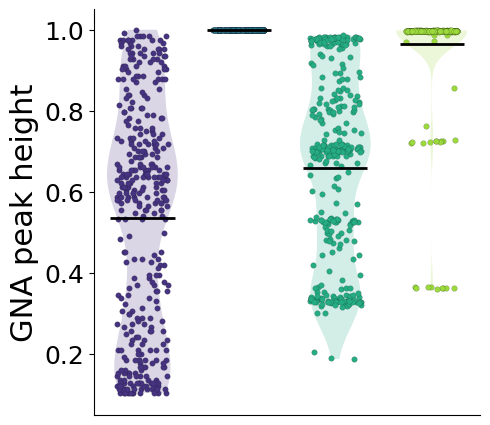

In [27]:
# ============================================================
# PLOT
# ============================================================
import subprocess
from pathlib import Path
from matplotlib.pylab import seed
import numpy as np
import matplotlib.pyplot as plt
from pypalettes import load_cmap 
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

fcn.compile_c_codes()

parameters2D = {
    "L": 3.0, # Length of the square domain (mm) or diameter of the circular domain (mm)
    "rho": 71, # Neuron density (neurons/mm^2)
    "soma_diameter": 0.015, # Diameter of the soma (mm)
    "d_mean": 0.15, # Dendritic tree diameter (mm) Gaussian distribution
    "d_sigma": 0.02, # Standard deviation of the dendritic tree diameter (mm)
    "l_mean": 1.0, # Mean axon length (mm) Rayleigh distribution
    "segment_length": 0.01, # Segment length for axon growth (mm)
    "sigma_axon_angle": 0.1, # Standard deviation of the axon angle (radians)
    "agg": 1, # Control parameter for the aggregation of neurons
    "n_centers": 10, # Number of centers for the aggregation of neurons
    "base_sigma": 0.03, # Base standard deviation for aggregation centers (mm)
    "BC_type": "SW",  # Boundary conditions type (PBC: Periodic Boundary Conditions, SW: Sticky Walls)
    "geometry": "square", # Geometry of the domain (square or circle)
    "seed": 0
}
alpha = 0.2

if parameters2D["geometry"] == "circle" and parameters2D["BC_type"] == "PBC":
    raise ValueError("Periodic Boundary Conditions (PBC) are not compatible with a circular geometry. Please choose 'SW' for BC_type or change the geometry to 'square'.")

if parameters2D["geometry"] == "square" or parameters2D["geometry"] == "squareLongRange":
    N = int(parameters2D["rho"] * parameters2D["L"]**2) # Total number of neurons
elif parameters2D["geometry"] == "circle":
    R = parameters2D["L"] / np.sqrt(np.pi)
    print(f"Effective radius of the circular domain: {R:.2f} mm")
    N = int(parameters2D["rho"] * np.pi * R**2) # Total number of neurons, same as in the square case for the same L, but we keep it here for clarity

# N = int((parameters2D["L"] / parameters2D["soma_diameter"])**2)

print(f"Number of neurons: {N}")
parametersDynamics = {
    "max_exc_weight": 7,
    "max_inh_weight": 0.5,
    "noise_max": 4,
    "sim_time": 50000,
    "seed": 42
}

axonal_lengths = [0.16, 1.0]
exc_weights = [8.5, 20.0]

simulate_dynamics = True
new_sim = True

filename_adj_list = []
filename_dynamics_list = []

case_info = []

for l_mean in axonal_lengths:

    parameters2D["l_mean"] = l_mean
    parameters2D["base_sigma"] = 0.03

    print(f"\nCreating network for l_mean={l_mean}")

    filename_neuron_params = fcn.run_2D_tune_positions(
        parameters2D,
        new_sim=new_sim
    )

    filename_network_tries = fcn.create_network2D(
        parameters2D,
        new_sim=new_sim
    )

    M = fcn.load_A(filename_network_tries)

    A, filename_adj_current = fcn.modify_A_alpha2D(
        M,
        alpha,
        parameters2D,
        new_sim=new_sim,
        GC=True
    )

    parametersDynamics["out_filename"] = filename_adj_current

    for exc_weight in exc_weights:

        print(f"Running dynamics for l_mean={l_mean}, exc_weight={exc_weight}")

        parametersDynamics["max_exc_weight"] = exc_weight

        filename_dynamics_current = fcn.run_dynamics_2D(
            parametersDynamics,
            parameters2D,
            alpha,
            new_sim=new_sim,
            show_prints_c=True
        )

        filename_adj_list.append(filename_adj_current)
        filename_dynamics_list.append(filename_dynamics_current)

        case_info.append({
            "l_mean": l_mean,
            "base_sigma": parameters2D["base_sigma"],
            "exc_weight": exc_weight,
            "filename_adj": filename_adj_current,
            "filename_dyn": filename_dynamics_current
        })

        import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def get_peak_heights_from_files(filename_adj, filename_dyn, SIM_TIME=10000, W=25):

    A = fcn.load_A(filename_adj)
    N = A.shape[0]

    firings_t, firings_i = fcn.load_firings(filename_dyn)

    GNA = fcn.compute_GNA_from_raster(
        firings_t=firings_t,
        firings_i=firings_i,
        N=N,
        SIM_TIME=SIM_TIME,
        W=W
    )

    peaks, peak_heights, mean_peaks_height, std_peaks_height = fcn.find_GNA_peaks(GNA)

    return np.asarray(peak_heights)

def plot_peak_height_violin_strip(
    peak_heights_list,
    labels,
    positions=None,
    colors=None,
    jitter=0.10,
    figsize=(5, 4.5),
    point_size=16,
    alpha_points=0.6,
    violin_alpha=0.5
):

    rng = np.random.default_rng(123)

    if positions is None:
        positions = np.arange(len(peak_heights_list))

    if colors is None:
        colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(peak_heights_list)))

    fig, ax = plt.subplots(figsize=figsize)

    vp = ax.violinplot(
        peak_heights_list,
        positions=positions,
        widths=0.22,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for body, color in zip(vp["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor("none")
        body.set_alpha(violin_alpha)
        body.set_zorder(5)

    for i, peak_heights in enumerate(peak_heights_list):

        peak_heights = np.asarray(peak_heights, dtype=float)
        peak_heights = peak_heights[np.isfinite(peak_heights)]

        x0 = positions[i]

        x = x0 + rng.uniform(
            -jitter,
            jitter,
            size=len(peak_heights)
        )

        ax.scatter(
            x,
            peak_heights,
            s=point_size,
            alpha=alpha_points,
            color=colors[i],
            edgecolor="black",
            linewidths=0.1,
            zorder=3
        )

        if len(peak_heights) > 0:
            mean_val = np.mean(peak_heights)

            ax.hlines(
                mean_val,
                x0 - 0.10,
                x0 + 0.10,
                color="black",
                linewidth=2.0,
                zorder=6
            )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=20)

    ax.tick_params(
        axis='x',
        which='both',
        bottom=False,
        top=False,
        labelbottom=False
    )

    ax.set_ylabel("GNA peak height", fontsize=22)

    ax.tick_params(axis="both", labelsize=18)

    ax.set_ylim(0, 1.05)
    # Quitar los bordes superior y derecho
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    return fig, ax


# ============================================================
# EXTRAER PICOS DE LOS FICHEROS QUE ACABAS DE CREAR
# ============================================================

peak_heights_list = []

for filename_adj, filename_dyn in zip(filename_adj_list, filename_dynamics_list):

    peak_heights = get_peak_heights_from_files(
        filename_adj,
        filename_dyn,
        SIM_TIME=50000,   # usa el mismo sim_time que has simulado
        W=25
    )

    peak_heights_list.append(peak_heights)
labels = [
    r"$\ell=0.16$" + "\n" + r"$E=8.5$",
    r"$\ell=0.16$" + "\n" + r"$E=20.0$",
    r"$\ell=1.00$" + "\n" + r"$E=8.5$",
    r"$\ell=1.00$" + "\n" + r"$E=20.0$",
]
labels = [
    f"",
    f"",
    f"",
    f"",
]

positions = [-0.1, 0.20, 0.50, 0.80]

colors = plt.cm.viridis(
    np.linspace(0.15, 0.85, len(peak_heights_list))
)

fig, ax = plot_peak_height_violin_strip(
    peak_heights_list,
    labels,
    positions=positions,
    colors=colors,
    figsize=(5, 4.5),
    jitter=0.08,
    point_size=16,
    alpha_points=1,
    violin_alpha=0.2
)

ax.set_xlim(-0.25, 0.95)
ax.set_ylim(0.05, 1.05)
plt.savefig(
    "figures_TFM/GNA_peak_height_violin_created_files.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)

plt.show()

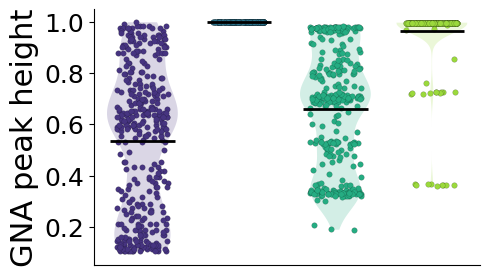

In [31]:
positions = [-0.1, 0.20, 0.50, 0.80]

colors = plt.cm.viridis(
    np.linspace(0.15, 0.85, len(peak_heights_list))
)

fig, ax = plot_peak_height_violin_strip(
    peak_heights_list,
    labels,
    positions=positions,
    colors=colors,
    figsize=(5, 3),
    jitter=0.08,
    point_size=16,
    alpha_points=1,
    violin_alpha=0.2
)

ax.set_xlim(-0.25, 0.95)
ax.set_ylim(0.05, 1.05)
plt.savefig(
    "figures_TFM/GNA_peak_height_violin_created_files.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)

plt.show()

# Map of Gini 

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


def plot_activity_panel(
    filename_left,
    filename_right,
    titles=("2D-Square", "3D-Cube"),
    heatmap_value="fano_factor",
    contour_value="mean_peaks_height",
    smooth_sigma=1.5,
    contour_levels=[0.2, 0.9],
    cmap="viridis",
    figsize=(12, 5.5)
):

    labels = {
        "fano_factor": r"$\langle F \rangle$",
        "mean_peaks_height": r"$\langle s \rangle$"
    }

    def make_grid(filename, value):
        df = pd.read_csv(filename, sep="\t")

        pivot = df.pivot(
            index="MAX_EXC_WEIGHT",
            columns="Gini",
            values=value
        ).sort_index()

        x = pivot.columns.to_numpy(dtype=float)
        y = pivot.index.to_numpy(dtype=float)
        Z = pivot.to_numpy(dtype=float)

        return x, y, Z

    # =========================
    # CARGA MATRICES
    # =========================

    x_left, y_left, Z_left_heat = make_grid(filename_left, heatmap_value)
    x_right, y_right, Z_right_heat = make_grid(filename_right, heatmap_value)

    _, _, Z_left_contour = make_grid(filename_left, contour_value)
    _, _, Z_right_contour = make_grid(filename_right, contour_value)

    Z_left_contour_smooth = gaussian_filter(Z_left_contour, sigma=smooth_sigma)
    Z_right_contour_smooth = gaussian_filter(Z_right_contour, sigma=smooth_sigma)

    # Escala común de color
    vmin = min(np.nanmin(Z_left_heat), np.nanmin(Z_right_heat))
    vmax = max(np.nanmax(Z_left_heat), np.nanmax(Z_right_heat))

    # Contornos automáticos
    if contour_levels is None:
        cmin = min(
            np.nanmin(Z_left_contour_smooth),
            np.nanmin(Z_right_contour_smooth)
        )
        cmax = max(
            np.nanmax(Z_left_contour_smooth),
            np.nanmax(Z_right_contour_smooth)
        )
        contour_levels = np.linspace(cmin, cmax, 6)[1:-1]

    # =========================
    # FIGURA
    # =========================

    fig, axs = plt.subplots(
        1, 2,
        figsize=figsize,
        sharey=True,
        gridspec_kw={"wspace": 0.08}
    )

    data = [
        (axs[0], x_left, y_left, Z_left_heat, Z_left_contour_smooth, titles[0]),
        (axs[1], x_right, y_right, Z_right_heat, Z_right_contour_smooth, titles[1])
    ]

    for ax, x, y, Z_heat, Z_contour, title in data:

        im = ax.imshow(
            Z_heat,
            origin="lower",
            aspect="auto",
            extent=[
                x.min(),
                x.max(),
                y.min(),
                y.max()
            ],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest"
        )

        cs = ax.contour(
            x,
            y,
            Z_contour,
            levels=contour_levels,
            colors="white",
            linewidths=1.5,
            linestyles="-"
        )

        ax.clabel(
            cs,
            inline=True,
            fontsize=15,
            fmt="%.2f"
        )

        ax.text(
            0.13,
            1.01,
            title,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=20,
            color="black",
            bbox=dict(
                facecolor="white",
                alpha=0.0,
                edgecolor="none",
                pad=6
            )
        )

        ax.set_xlabel(r"$\Lambda$", fontsize=22)

        ax.tick_params(
            axis="both",
            labelsize=18,
            length=6,
            width=1.2
        )

    axs[0].set_ylabel(r"$g_E$", fontsize=22)

    # Colorbar común
    cbar = fig.colorbar(
        im,
        ax=axs,
        location="right",
        fraction=0.045,
        pad=0.025
    )

    cbar.ax.set_title(
        labels[heatmap_value],
        fontsize=20,
        pad=14
    )

    cbar.ax.tick_params(labelsize=18)

    plt.savefig("figures_TFM/fano_factor_panel_Gini.png", dpi=600, bbox_inches="tight", transparent = True)
    plt.show()

In [18]:
from pathlib import Path

# Ficheros en el orden correcto
files = [
    "GNA_map_vsGini/3D_GNAmap_cube_SW_rho600_l1.00_sim0_ch0.txt",
    "GNA_map_vsGini/3D_GNAmap_cube_SW_rho600_l1.00_sim0_ch1.txt",
    "GNA_map_vsGini/3D_GNAmap_cube_SW_rho600_l1.00_sim0_ch2.txt",
    "GNA_map_vsGini/3D_GNAmap_cube_SW_rho600_l1.00_sim0_ch3.txt",
]

# Nombre del fichero de salida
output = files[0].replace("_ch0", "")

with open(output, "w") as fout:

    for file in files:

        with open(file, "r") as fin:
            lines = fin.readlines()

        # Eliminar la cabecera
        fout.writelines(lines[1:])

print(f"Creado: {output}")

Creado: GNA_map_vsGini/3D_GNAmap_cube_SW_rho600_l1.00_sim0.txt


In [10]:
import pandas as pd
import numpy as np


# ============================================
# FICHEROS A PROMEDIAR
# ============================================

sims = 2

files = [f"GNA_map_vsGini/3D_GNAmap_cube_SW_rho600_l1.00_sim{i}.txt" for i in range(sims)]

# files = [
#     "GNA_map_vsGini/GNAmap_square_SW_rho125_l1.10_sim0_ch0.txt",
#     "GNA_map_vsGini/GNAmap_square_SW_rho125_l1.10_sim1_ch0.txt",
#     "GNA_map_vsGini/GNAmap_square_SW_rho125_l1.10_sim2_ch0.txt"
# ]

# Nombre del fichero de salida
output_file = "GNA_map_vsGini/3D_GNAmap_cube_SW_rho600_l1.00_mean.txt"


# ============================================
# LEER TODOS LOS DATAFRAMES
# ============================================

dfs = [
    pd.read_csv(f, sep="\t")
    for f in files
]


# ============================================
# COLUMNAS NUMÉRICAS A PROMEDIAR
# ============================================

numeric_cols = [
    "Gini",
    "mean_peaks_height",
    "std_peaks_height",
    "fano_factor"
]


# ============================================
# CONCATENAR Y PROMEDIAR
# ============================================

df_all = pd.concat(dfs)

df_mean = (
    df_all
    .groupby(["base_sigma", "MAX_EXC_WEIGHT"], as_index=False)
    [numeric_cols]
    .mean()
)


# ============================================
# GUARDAR
# ============================================

df_mean.to_csv(
    output_file,
    sep="\t",
    index=False
)

print(f"Archivo guardado en:\n{output_file}")

Archivo guardado en:
GNA_map_vsGini/3D_GNAmap_cube_SW_rho600_l1.00_mean.txt


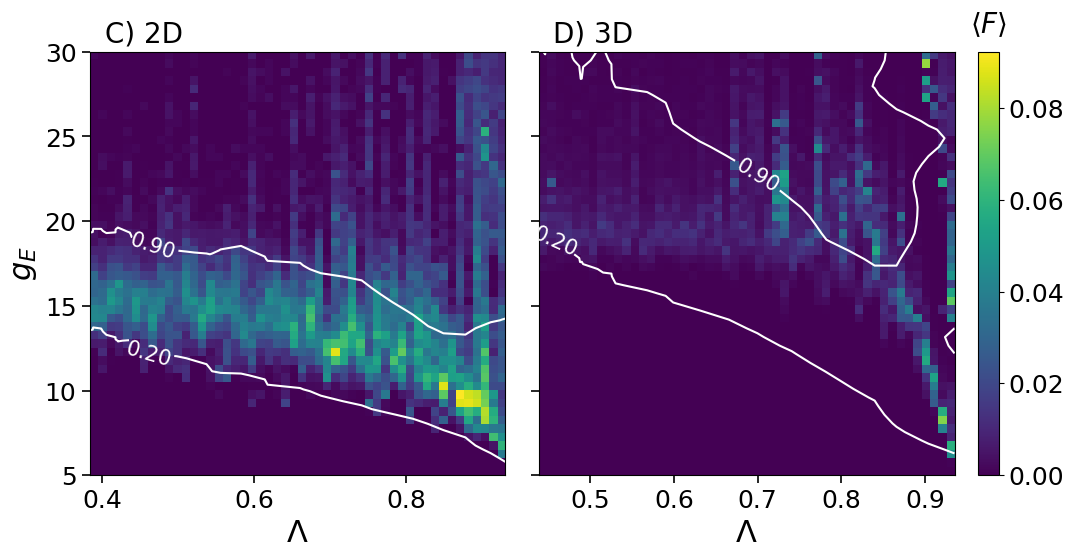

In [36]:
plot_activity_panel(
    filename_left="GNA_map_vsGini/GNAmap_square_SW_rho71_l1.00_mean.txt",
    filename_right="GNA_map_vsGini/3D_GNAmap_cube_SW_rho600_l1.00_sim0.txt",
    titles=("C) 2D", "D) 3D"),
    heatmap_value="fano_factor",
    contour_value="mean_peaks_height", 
    smooth_sigma=1.5,
)

<Axes: xlabel='$g_E$', ylabel='$\\langle s\\rangle$'>

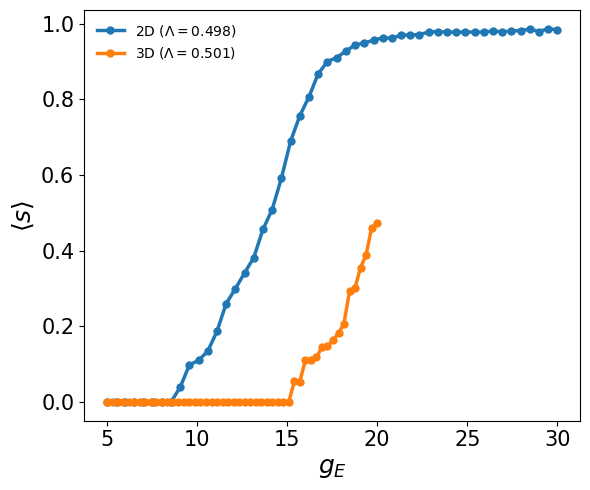

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_curve_fixed_gini(
    filename_2D,
    filename_3D,
    gini_target,
    value="fano_factor",
    labels=("2D", "3D"),
    figsize=(6,5),
    ax=None
):
    """
    Extrae una curva a Gini fijo de dos mapas (2D y 3D).

    Parameters
    ----------
    filename_2D : str
    filename_3D : str
    gini_target : float
    value : str
        Columna a representar.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    for filename, label in zip(
        [filename_2D, filename_3D],
        labels
    ):

        df = pd.read_csv(filename, sep="\t")

        pivot = df.pivot(
            index="MAX_EXC_WEIGHT",
            columns="Gini",
            values=value
        ).sort_index()

        ginis = pivot.columns.to_numpy(dtype=float)

        idx = np.argmin(np.abs(ginis - gini_target))

        gini_real = ginis[idx]

        y = pivot.index.to_numpy(dtype=float)
        z = pivot.iloc[:, idx].to_numpy(dtype=float)

        ax.plot(
            y,
            z,
            "-o",
            lw=2.5,
            ms=5,
            label=f"{label} ($\\Lambda={gini_real:.3f}$)"
        )

    ylabel = {
        "fano_factor": r"$\langle F\rangle$",
        "mean_peaks_height": r"$\langle s\rangle$",
        "GC_fraction": "GCS",
        "mean_degree": r"$\langle k\rangle$"
    }

    ax.set_xlabel(r"$g_E$", fontsize=18)
    ax.set_ylabel(ylabel.get(value, value), fontsize=18)

    ax.tick_params(labelsize=15)

    ax.legend(frameon=False)

    plt.tight_layout()

    return ax

plot_curve_fixed_gini(
    filename_2D="GNA_map_vsGini/GNAmap_square_SW_rho71_l1.00_mean.txt",
    filename_3D="GNA_map_vsGini/3D_GNAmap_cube_SW_rho600_l1.00_mean.txt",
    gini_target=0.5,
    value="mean_peaks_height",
    labels=("2D", "3D"),
    figsize=(6,5)
)

In [48]:
import os

def find_filename2D(parameters2D = None, sigma = 0.5, exc_weight = 8.5, sim_number = 0):

    if parameters2D is None:
        parameters2D = {
            "L": 3.0,
            "rho": 71,
            "soma_diameter": 0.015,
            "d_mean": 0.15,
            "d_sigma": 0.02,
            "l_mean": 1.00,
            "segment_length": 0.01,
            "sigma_axon_angle": 0.1,
            "agg": 1,
            "n_centers": 10,
            "base_sigma": 0.5,
            "BC_type": "SW",
            "geometry": "square"   # "square" or "circle"
    }

    parametersDynamics = {
        "max_exc_weight": 8.5,
        "max_inh_weight": 0.5,
        "noise_max": 3,
        "sim_time": 10000,
        "seed": 42
    }

    alpha = 0.2
    sim = sim_number

    # calibration_filename = "figures_TFM/data_for_figures/gini2D_n_grid13_calibration.txt"
    # data = np.loadtxt(calibration_filename, skiprows=1)
    # base_sigma_values = data[:,1]

    base_sigmas = np.linspace(0.03, 0.7, 50)
    MAX_EXC_WEIGHT_values = np.linspace(5, 30.0, 50)


    base_sigma_target = sigma
    MAX_EXC_WEIGHT_target = exc_weight

    base_sigma = base_sigmas[np.abs(base_sigmas - base_sigma_target).argmin()]
    # print("base_Sigma found:", base_sigma)
    MAX_EXC_WEIGHT = MAX_EXC_WEIGHT_values[np.abs(MAX_EXC_WEIGHT_values - MAX_EXC_WEIGHT_target).argmin()]

    # print("Selected base_sigma:", base_sigma)
    # print("Selected MAX_EXC_WEIGHT:", MAX_EXC_WEIGHT)
    # ============================================================
    # FILENAMES
    # ============================================================


    filename_adj_2D = (
        f"2D_dynamics/networks_for_dynamics/"
        f"2D_adjacency_matrix_{parameters2D['geometry']}_{parameters2D['BC_type']}"
        f"_agg_nc{parameters2D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}"
        f"_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}"
        f"_a{alpha:.2f}_sim{sim}.txt"
    )

    filename_dyn_2D = (
        f"2D_dynamics/2D_dynamics_{parameters2D['geometry']}_{parameters2D['BC_type']}"
        f"_agg_nc{parameters2D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}"
        f"_a{alpha:.2f}_exc{MAX_EXC_WEIGHT:.3f}_sim{sim}.txt"
    )

    if not os.path.exists(filename_adj_2D):
        print(f"Archivo no encontrado: {filename_adj_2D}")
    if not os.path.exists(filename_dyn_2D):
        print(f"Archivo no encontrado: {filename_dyn_2D}")
        
    return filename_adj_2D, filename_dyn_2D

def find_filename3D(parameters3D = None, sigma = 0.04, exc_weight = 8.5, sim_number = 0):

    if parameters3D is None:
        parameters3D = {
            "L": 3.0, # Length of the square domain (mm) or diameter of the circular domain (mm)
            "height": 1.0, # Height of the cylinder domain (mm), only used if geometry is "cylinder"
            "rho": 600, # Neuron density (neurons/mm^2)
            "soma_diameter": 0.015, # Diameter of the soma (mm)
            "d_mean": 0.15, # Dendritic tree diameter (mm) Gaussian distribution
            "d_sigma": 0.02, # Standard deviation of the dendritic tree diameter (mm)
            "l_mean": 1.00, # Mean axon length (mm) Rayleigh distribution
            "segment_length": 0.01, # Segment length for axon growth (mm)
            "sigma_pol": 0.1, # Standard deviation of the axon angle (radians)
            "sigma_azi": 0.1, # Standard deviation of the azimuthal angle (radians)
            "agg": 1, # Control parameter for the aggregation of neurons
            "n_centers": 84, # Number of centers for the aggregation of neurons
            "base_sigma": 0.04, # Base standard deviation for aggregation centers (mm)
            "BC_type": "SW",  # Boundary conditions type (PBC: Periodic Boundary Conditions, SW: Sticky Walls)
            "geometry": "cube", # Geometry of the domain (cube or sphere)
            "seed": 0,
    }

    parametersDynamics = {
        "max_exc_weight": 8.5,
        "max_inh_weight": 0.5,
        "noise_max": 3,
        "sim_time": 10000,
        "seed": 42
    }

    alpha = 0.2
    sim = sim_number

    # calibration_filename = "figures_TFM/data_for_figures/gini3D_n_grid13_calibration.txt"
    # data = np.loadtxt(calibration_filename, skiprows=1)
    # base_sigma_values = data[:,1]

    base_sigmas = np.linspace(0.03, 0.7, 50)
    MAX_EXC_WEIGHT_values = np.linspace(5, 30.0, 50)


    base_sigma_target = sigma
    MAX_EXC_WEIGHT_target = exc_weight

    base_sigma = base_sigmas[np.abs(base_sigmas - base_sigma_target).argmin()]
    MAX_EXC_WEIGHT = MAX_EXC_WEIGHT_values[np.abs(MAX_EXC_WEIGHT_values - MAX_EXC_WEIGHT_target).argmin()]

    # print("Selected base_sigma:", base_sigma)
    # print("Selected MAX_EXC_WEIGHT:", MAX_EXC_WEIGHT)
    # sunset2 = load_cmap("Sunset2", cmap_type="continuous")

    # ============================================================
    # FILENAMES
    # ============================================================

    filename_adj_3D = (
        f"3D_dynamics/networks_for_dynamics/"
        f"3D_adjacency_matrix_{parameters3D['geometry']}_{parameters3D['BC_type']}"
        f"_agg_nc{parameters3D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters3D['L']:.1f}_h{parameters3D['height']:.2f}_rho{parameters3D['rho']:.0f}"
        f"_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}"
        f"_a{alpha:.2f}_sim{sim}.txt"
    )

    filename_dyn_3D = (
        f"3D_dynamics/3D_dynamics_{parameters3D['geometry']}_{parameters3D['BC_type']}"
        f"_agg_nc{parameters3D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters3D['L']:.1f}_h{parameters3D['height']:.2f}_rho{parameters3D['rho']:.0f}"
        f"_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}"
        f"_a{alpha:.2f}_exc{MAX_EXC_WEIGHT:.3f}_sim{sim}.txt"
    )

    if not os.path.exists(filename_adj_3D):
        print(f"Archivo no encontrado: {filename_adj_3D}")
    if not os.path.exists(filename_dyn_3D):
        print(f"Archivo no encontrado: {filename_dyn_3D}")
    return filename_adj_3D, filename_dyn_3D


import numpy as np
import matplotlib.pyplot as plt
from pypalettes import load_cmap

viridis = load_cmap("viridis", cmap_type="continuous")

def plot_raster_only(
    filename_adj,
    filename_dyn,
    SIM_TIME=10000,
    xlim=None,
    reorder=True,
    title=None,
    savefig=None
):
    # =========================
    # Cargar red para saber N
    # =========================
    A = fcn.load_A(filename_adj)
    A_GC = fcn.get_GC(A)

    # Si la dinámica está hecha sobre la giant component
    N = A_GC.shape[0]

    # =========================
    # Cargar disparos
    # =========================
    firings_t, firings_i = fcn.load_firings(filename_dyn)

    firings_t = np.asarray(firings_t)
    firings_i = np.asarray(firings_i, dtype=int)

    # =========================
    # Reordenar neuronas si quieres
    # =========================
    if reorder:
        F, F_binary, F_ordered, order, communities = fcn.build_F_matrix(
            filename_dyn,
            SIM_TIME=SIM_TIME,
            N=N
        )

        old_to_new = np.empty(N, dtype=int)
        old_to_new[order] = np.arange(N)

        firings_i_0 = firings_i - 1

        valid = (firings_i_0 >= 0) & (firings_i_0 < N)

        firings_t_plot = firings_t[valid]
        firings_i_plot = old_to_new[firings_i_0[valid]] + 1

    else:
        firings_i_0 = firings_i - 1

        valid = (firings_i_0 >= 0) & (firings_i_0 < N)

        firings_t_plot = firings_t[valid]
        firings_i_plot = firings_i[valid]

    # =========================
    # Pasar tiempo a segundos
    # =========================
    firings_t_plot = firings_t_plot / 1000

    if xlim is None:
        xlim_plot = SIM_TIME / 1000
    else:
        xlim_plot = xlim / 1000

    # =========================
    # Plot raster
    # =========================
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.scatter(
        firings_t_plot,
        firings_i_plot,
        s=0.5,
        color=viridis(0.1)
    )

    ax.set_xlabel("Time (s)", fontsize=18)
    ax.set_ylabel("Neurons", fontsize=18)

    ax.set_ylim(N, 0)
    ax.set_xlim(0, xlim_plot)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=14,
        length=6,
        width=1.2
    )

    if title is not None:
        ax.set_title(title, fontsize=18)

    plt.tight_layout()

    if savefig is not None:
        plt.savefig(savefig, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, ax


def plot_raster_gna(
    filename_adj,
    filename_dyn,
    SIM_TIME=10000,
    xlim=None,
    reorder=True,
    title=None,
    savefig=None,
    W=25,
    s=1.0,
    lw=1.5,
    show_axes_labels=True
):

    A = fcn.load_A(filename_adj)
    A_GC = fcn.get_GC(A)
    N = A_GC.shape[0]

    firings_t, firings_i = fcn.load_firings(filename_dyn)
    firings_t = np.asarray(firings_t)
    firings_i = np.asarray(firings_i, dtype=int)

    # =====================================================
    # Reordenar neuronas
    # =====================================================
    if reorder:

        F, F_binary, F_ordered, order, communities = fcn.build_F_matrix(
            filename_dyn,
            SIM_TIME=SIM_TIME,
            N=N
        )

        old_to_new = np.empty(N, dtype=int)
        old_to_new[order] = np.arange(N)

        firings_i_0 = firings_i - 1
        valid = (firings_i_0 >= 0) & (firings_i_0 < N)

        firings_t_plot = firings_t[valid]
        firings_i_plot = old_to_new[firings_i_0[valid]] + 1

    else:

        firings_i_0 = firings_i - 1
        valid = (firings_i_0 >= 0) & (firings_i_0 < N)

        firings_t_plot = firings_t[valid]
        firings_i_plot = firings_i[valid]

    # =====================================================
    # GNA
    # =====================================================
    GNA = fcn.compute_GNA_from_raster(
        firings_t,
        firings_i,
        N=N,
        SIM_TIME=SIM_TIME,
        W=W
    )

    peaks, peak_heights, mean_peak_height, std_peak_height = (
        fcn.find_GNA_peaks(GNA)
    )

    # =====================================================
    # Tiempo en segundos
    # =====================================================
    firings_t_plot = firings_t_plot / 1000
    t_gna = np.arange(1, SIM_TIME + 1) / 1000
    peaks_plot = peaks / 1000

    if xlim is None:
        xlim_plot = SIM_TIME / 1000
    else:
        xlim_plot = xlim / 1000

    # =====================================================
    # Figura
    # =====================================================
    fig = plt.figure(figsize=(3, 4))

    gs = fig.add_gridspec(
        2, 1,
        height_ratios=[3, 1],
        hspace=0.1
    )

    # =====================================================
    # Raster
    # =====================================================
    ax_raster = fig.add_subplot(gs[0, 0])

    ax_raster.scatter(
        firings_t_plot,
        firings_i_plot,
        s=s,
        color=viridis(0.2),
        marker="."
    )

    ax_raster.set_ylim(N, 0)
    ax_raster.set_xlim(0, xlim_plot)

    ax_raster.tick_params(
        axis="both",
        which="major",
        labelsize=14,
        length=6,
        width=1.2
    )

    ax_raster.tick_params(axis="x", labelbottom=False)

    if show_axes_labels:
        ax_raster.set_ylabel("Neurons", fontsize=18)
    else:
        ax_raster.set_ylabel("")
        ax_raster.tick_params(axis="y", labelleft=False)

    # =====================================================
    # GNA
    # =====================================================
    ax_gna = fig.add_subplot(gs[1, 0], sharex=ax_raster)

    ax_gna.plot(
        t_gna,
        GNA,
        lw=lw,
        color=viridis(0.2)
    )

    # Si quieres mostrar los picos, descomenta esto
    # ax_gna.scatter(
    #     peaks_plot,
    #     GNA[peaks],
    #     c="red",
    #     s=15,
    #     zorder=5
    # )

    ax_gna.set_xlim(0, xlim_plot)

    ax_gna.tick_params(
        axis="both",
        which="major",
        labelsize=14,
        length=6,
        width=1.2
    )

    if show_axes_labels:
        ax_gna.set_xlabel("Time (s)", fontsize=18)
        ax_gna.set_ylabel("GNA", fontsize=18)
    else:
        ax_gna.set_xlabel("")
        ax_gna.set_ylabel("")
        ax_gna.tick_params(axis="x", labelbottom=False)
        ax_gna.tick_params(axis="y", labelleft=False)

    # =====================================================
    # Título
    # =====================================================
    if title is not None:
        fig.suptitle(title, fontsize=18, y=0.98)

    plt.tight_layout()

    if savefig is not None:
        plt.savefig(savefig, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, ax_raster, ax_gna

In [62]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import warnings
warnings.filterwarnings("ignore")

exc_weight = np.linspace(2, 30.0, 50)

sigma_2D_1 = 0.7
exc_weight_2D_1 = 15
sigma_2D_2 = 0.05
exc_weight_2D_2 = 8.2
sigma_3D_1 = 0.5
exc_weight_3D_1 = 15
sigma_3D_2 = 0.03
exc_weight_3D_2 = 10

sim_number = 0
filename_2D_1= find_filename2D(sigma=sigma_2D_1, exc_weight=exc_weight_2D_1, sim_number = sim_number)
filename_2D_2 = find_filename2D(sigma=sigma_2D_2, exc_weight=exc_weight_2D_2, sim_number = sim_number)
filename_3D_1= find_filename3D(sigma=sigma_3D_1, exc_weight=exc_weight_3D_1)
filename_3D_2 = find_filename3D(sigma=sigma_3D_2, exc_weight=exc_weight_3D_2)


# print(f"2D-1: {filename_2D_1}")

filename_2D_1_adj = filename_2D_1[0]
filename_2D_2_adj = filename_2D_2[0]
filename_3D_1_adj = filename_3D_1[0]
filename_3D_2_adj = filename_3D_2[0]

filename_2D_1_dyn = filename_2D_1[1]
filename_2D_2_dyn = filename_2D_2[1]
filename_3D_1_dyn = filename_3D_1[1]
filename_3D_2_dyn = filename_3D_2[1]

plot_raster_gna(
    filename_adj=filename_2D_1_adj,
    filename_dyn=filename_2D_1_dyn,
    SIM_TIME=10000,
    xlim=10000,
    reorder=False,
    title="",
    savefig="figures_TFM/raster_2D_agg.svg", 
    s = 0.5,
    lw = 0.9,
    show_axes_labels=True
)



Archivo no encontrado: 3D_dynamics/networks_for_dynamics/3D_adjacency_matrix_cube_SW_agg_nc84_s0.4949_L3.0_h1.00_rho600_l1.00_d0.15_a0.20_sim0.txt
Archivo no encontrado: 3D_dynamics/3D_dynamics_cube_SW_agg_nc84_s0.4949_L3.0_h1.00_rho600_l1.00_d0.15_a0.20_exc15.204_sim0.txt
Archivo no encontrado: 3D_dynamics/3D_dynamics_cube_SW_agg_nc84_s0.0300_L3.0_h1.00_rho600_l1.00_d0.15_a0.20_exc10.102_sim0.txt


IndexError: index 625 is out of bounds for axis 0 with size 625

# Functional analysis

## ROC curves, confusion matrices

In [98]:
from sklearn.metrics import roc_curve, auc
import numpy as np


def compute_roc(A, F):

    # -------------------------
    # Simetrizar estructura
    # -------------------------
    F = np.nan_to_num(F, nan=0.0)

    A = ((A + A.T) > 0).astype(int)

    # -------------------------
    # Score funcional
    # -------------------------

    F = np.abs(F)

    # -------------------------
    # Triángulo superior
    # -------------------------

    mask = np.triu(np.ones(A.shape, dtype=bool), k=1)

    y_true = A[mask]
    y_score = F[mask]

    # -------------------------
    # ROC
    # -------------------------

    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    roc_auc = auc(fpr, tpr)

    return fpr, tpr, roc_auc, thresholds

def confusion_at_fpr(A, F, target_fpr=0.1):

    F = np.nan_to_num(F, nan=0.0)
    A = ((A + A.T) > 0).astype(int)
    F = np.abs(F)

    mask = np.triu(np.ones(A.shape, dtype=bool), k=1)

    y_true = A[mask]
    y_score = F[mask]

    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    idx = np.argmin(np.abs(fpr - target_fpr))
    threshold = thresholds[idx]

    y_pred = (y_score >= threshold).astype(int)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    TN = np.sum((y_true == 0) & (y_pred == 0))

    return {
        "threshold": threshold,
        "fpr": FP / (FP + TN),
        "tpr": TP / (TP + FN),
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,
        "P": TP + FN,
        "N": FP + TN
    }

import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from mpl_toolkits.axes_grid1 import make_axes_locatable

from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_confusion_matrix_normalized(res, title=""):

    cm = np.array([
        [res["TP"] / res["P"], res["FN"] / res["P"]],
        [res["FP"] / res["N"], res["TN"] / res["N"]]
    ])

    labels = [["TPR", "FNR"],
              ["FPR", "TNR"]]

    fig, ax = plt.subplots(figsize=(5, 4.5))

    im = ax.imshow(cm, cmap="viridis", vmin=0, vmax=1, aspect="equal")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.08)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label("Fraction", fontsize=20)
    cbar.ax.tick_params(labelsize=18)
    cbar.outline.set_edgecolor("#ccc")

    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = plt.get_cmap("viridis")

    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            r, g, b, _ = cmap(norm(val))
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            text_color = "white" if luminance < 0.5 else "#111"
            ax.text(
                j, i,
                f"{labels[i][j]}\n{100 * val:.1f}%",
                ha="center", va="center",
                fontsize=15, fontweight="bold",
                color=text_color,
                linespacing=1.6
            )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Positive", "Negative"], fontsize=18)
    ax.set_yticklabels(["Positive", "Negative"], fontsize=18, rotation=90, va="center")
    ax.tick_params(length=0)

    ax.set_xlabel("Predicted", fontsize=20, fontweight="medium", labelpad=8)
    ax.set_ylabel("Actual", fontsize=20, fontweight="medium", labelpad=8)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(title, fontsize=17, pad=14, fontweight="medium")

    plt.tight_layout()
    plt.show()

In [77]:
import os


def find_filename2D(parameters2D = None, sigma = 0.5, exc_weight = 8.5, sim_number = 0):

    if parameters2D is None:
        parameters2D = {
            "L": 3.0,
            "rho": 71,
            "soma_diameter": 0.015,
            "d_mean": 0.15,
            "d_sigma": 0.02,
            "l_mean": 1.00,
            "segment_length": 0.01,
            "sigma_axon_angle": 0.1,
            "agg": 1,
            "n_centers": 10,
            "base_sigma": 0.5,
            "BC_type": "SW",
            "geometry": "square"   # "square" or "circle"
    }

    parametersDynamics = {
        "max_exc_weight": 8.5,
        "max_inh_weight": 0.5,
        "noise_max": 3,
        "sim_time": 10000,
        "seed": 42
    }

    alpha = 0.2
    sim = sim_number

    calibration_filename = "figures_TFM/data_for_figures/gini2D_n_grid13_calibration.txt"
    data = np.loadtxt(calibration_filename, skiprows=1)
    base_sigma_values = data[:,1]

    base_sigma_values = np.linspace(0.03, 0.7, 50)
    MAX_EXC_WEIGHT_values = np.linspace(5, 30.0, 50)


    base_sigma_target = sigma
    MAX_EXC_WEIGHT_target = exc_weight

    base_sigma = base_sigma_values[np.abs(base_sigma_values - base_sigma_target).argmin()]
    MAX_EXC_WEIGHT = MAX_EXC_WEIGHT_values[np.abs(MAX_EXC_WEIGHT_values - MAX_EXC_WEIGHT_target).argmin()]


    # ============================================================
    # FILENAMES
    # ============================================================


    filename_adj_2D = (
        f"2D_dynamics/networks_for_dynamics/"
        f"2D_adjacency_matrix_{parameters2D['geometry']}_{parameters2D['BC_type']}"
        f"_agg_nc{parameters2D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}"
        f"_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}"
        f"_a{alpha:.2f}_sim{sim}.txt"
    )

    filename_dyn_2D = (
        f"2D_dynamics/2D_dynamics_{parameters2D['geometry']}_{parameters2D['BC_type']}"
        f"_agg_nc{parameters2D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}"
        f"_a{alpha:.2f}_exc{MAX_EXC_WEIGHT:.3f}_sim{sim}.txt"
    )

    if not os.path.exists(filename_adj_2D):
        print(f"Archivo no encontrado: {filename_adj_2D}")
    if not os.path.exists(filename_dyn_2D):
        print(f"Archivo no encontrado: {filename_dyn_2D}")
        
    return filename_adj_2D, filename_dyn_2D

def find_filename3D(parameters3D = None, sigma = 0.04, exc_weight = 8.5, sim_number = 0):

    if parameters3D is None:
        parameters3D = {
            "L": 3.0, # Length of the square domain (mm) or diameter of the circular domain (mm)
            "height": 1.0, # Height of the cylinder domain (mm), only used if geometry is "cylinder"
            "rho": 600, # Neuron density (neurons/mm^2)
            "soma_diameter": 0.015, # Diameter of the soma (mm)
            "d_mean": 0.15, # Dendritic tree diameter (mm) Gaussian distribution
            "d_sigma": 0.02, # Standard deviation of the dendritic tree diameter (mm)
            "l_mean": 1.00, # Mean axon length (mm) Rayleigh distribution
            "segment_length": 0.01, # Segment length for axon growth (mm)
            "sigma_pol": 0.1, # Standard deviation of the axon angle (radians)
            "sigma_azi": 0.1, # Standard deviation of the azimuthal angle (radians)
            "agg": 1, # Control parameter for the aggregation of neurons
            "n_centers": 80, # Number of centers for the aggregation of neurons
            "base_sigma": 0.04, # Base standard deviation for aggregation centers (mm)
            "BC_type": "SW",  # Boundary conditions type (PBC: Periodic Boundary Conditions, SW: Sticky Walls)
            "geometry": "cube", # Geometry of the domain (cube or sphere)
            "seed": 0,
    }

    parametersDynamics = {
        "max_exc_weight": 8.5,
        "max_inh_weight": 0.5,
        "noise_max": 3,
        "sim_time": 10000,
        "seed": 42
    }

    alpha = 0.2
    sim = sim_number

    calibration_filename = "figures_TFM/data_for_figures/gini3D_n_grid13_calibration.txt"
    data = np.loadtxt(calibration_filename, skiprows=1)
    base_sigma_values = data[:,1]

    base_sigma_values = np.linspace(0.03, 0.7, 50)
    MAX_EXC_WEIGHT_values = np.linspace(5, 30.0, 50)


    base_sigma_target = sigma
    MAX_EXC_WEIGHT_target = exc_weight

    base_sigma = base_sigma_values[np.abs(base_sigma_values - base_sigma_target).argmin()]
    MAX_EXC_WEIGHT = MAX_EXC_WEIGHT_values[np.abs(MAX_EXC_WEIGHT_values - MAX_EXC_WEIGHT_target).argmin()]

    sunset2 = load_cmap("Sunset2", cmap_type="continuous")

    # ============================================================
    # FILENAMES
    # ============================================================

    filename_adj_3D = (
        f"3D_dynamics/networks_for_dynamics/"
        f"3D_adjacency_matrix_{parameters3D['geometry']}_{parameters3D['BC_type']}"
        f"_agg_nc{parameters3D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters3D['L']:.1f}_h{parameters3D['height']:.2f}_rho{parameters3D['rho']:.0f}"
        f"_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}"
        f"_a{alpha:.2f}_sim{sim}.txt"
    )

    filename_dyn_3D = (
        f"3D_dynamics/3D_dynamics_{parameters3D['geometry']}_{parameters3D['BC_type']}"
        f"_agg_nc{parameters3D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters3D['L']:.1f}_h{parameters3D['height']:.2f}_rho{parameters3D['rho']:.0f}"
        f"_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}"
        f"_a{alpha:.2f}_exc{MAX_EXC_WEIGHT:.3f}_sim{sim}.txt"
    )

    if not os.path.exists(filename_adj_3D):
        print(f"Archivo no encontrado: {filename_adj_3D}")
    if not os.path.exists(filename_dyn_3D):
        print(f"Archivo no encontrado: {filename_dyn_3D}")
    return filename_adj_3D, filename_dyn_3D

In [80]:
# -----------------------------
# Parámetros
# -----------------------------

import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

sigma_2D_1 = 0.7
exc_weight_2D_1 = 15

sigma_2D_2 = 0.03
exc_weight_2D_2 = 9

sigma_3D_1 = 0.6
exc_weight_3D_1 = 14

sigma_3D_2 = 0.04
exc_weight_3D_2 = 9.8

SIM_TIME = 10000


# -----------------------------
# Ficheros
# -----------------------------

filename_adj_2D_1, filename_dyn_2D_1 = find_filename2D(
    sigma=sigma_2D_1,
    exc_weight=exc_weight_2D_1
)

filename_adj_2D_2, filename_dyn_2D_2 = find_filename2D(
    sigma=sigma_2D_2,
    exc_weight=exc_weight_2D_2
)

filename_adj_3D_1, filename_dyn_3D_1 = find_filename3D(
    sigma=sigma_3D_1,
    exc_weight=exc_weight_3D_1
)

filename_adj_3D_2, filename_dyn_3D_2 = find_filename3D(
    sigma=sigma_3D_2,
    exc_weight=exc_weight_3D_2
)


# -----------------------------
# Cargar matrices estructurales
# -----------------------------

A_2D_1 = fcn.load_A(filename_adj_2D_1)
A_2D_2 = fcn.load_A(filename_adj_2D_2)
A_3D_1 = fcn.load_A(filename_adj_3D_1)
A_3D_2 = fcn.load_A(filename_adj_3D_2)

A_2D_1_CG = fcn.get_GC(A_2D_1)
A_2D_2_CG = fcn.get_GC(A_2D_2)
A_3D_1_CG = fcn.get_GC(A_3D_1)
A_3D_2_CG = fcn.get_GC(A_3D_2)


# -----------------------------
# Construir matrices funcionales
# -----------------------------

F_2D_1 = fcn.build_F_matrix(
    filename_dyn_2D_1,
    SIM_TIME=SIM_TIME,
    N=A_2D_1_CG.shape[0]
)[0]

F_2D_2 = fcn.build_F_matrix(
    filename_dyn_2D_2,
    SIM_TIME=SIM_TIME,
    N=A_2D_2_CG.shape[0]
)[0]

F_3D_1 = fcn.build_F_matrix(
    filename_dyn_3D_1,
    SIM_TIME=SIM_TIME,
    N=A_3D_1_CG.shape[0]
)[0]

F_3D_2 = fcn.build_F_matrix(
    filename_dyn_3D_2,
    SIM_TIME=SIM_TIME,
    N=A_3D_2_CG.shape[0]
)[0]


# -----------------------------
# Comprobar tamaños
# -----------------------------

print("2D 1:", A_2D_1_CG.shape, F_2D_1.shape)
print("2D 2:", A_2D_2_CG.shape, F_2D_2.shape)
print("3D 1:", A_3D_1_CG.shape, F_3D_1.shape)
print("3D 2:", A_3D_2_CG.shape, F_3D_2.shape)


# -----------------------------
# ROC
# -----------------------------

fpr_2D_1, tpr_2D_1, roc_auc_2D_1, thresholds_2D_1 = compute_roc(
    A_2D_1_CG,
    F_2D_1
)

fpr_2D_2, tpr_2D_2, roc_auc_2D_2, thresholds_2D_2 = compute_roc(
    A_2D_2_CG,
    F_2D_2
)

fpr_3D_1, tpr_3D_1, roc_auc_3D_1, thresholds_3D_1 = compute_roc(
    A_3D_1_CG,
    F_3D_1
)

fpr_3D_2, tpr_3D_2, roc_auc_3D_2, thresholds_3D_2 = compute_roc(
    A_3D_2_CG,
    F_3D_2
)


# -----------------------------
# Confusion matrices a FPR = 0.1
# -----------------------------

res_2D_1 = confusion_at_fpr(A_2D_1_CG, F_2D_1, target_fpr=0.1)
res_2D_2 = confusion_at_fpr(A_2D_2_CG, F_2D_2, target_fpr=0.1)
res_3D_1 = confusion_at_fpr(A_3D_1_CG, F_3D_1, target_fpr=0.1)
res_3D_2 = confusion_at_fpr(A_3D_2_CG, F_3D_2, target_fpr=0.1)

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-p

2D 1: (625, 625) (625, 625)
2D 2: (639, 639) (639, 639)
3D 1: (5035, 5035) (5035, 5035)
3D 2: (5357, 5357) (5357, 5357)


(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, -0.2, '−0.2'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4000000000000001, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0000000000000002, '1.0'),
  Text(0, 1.2000000000000002, '1.2')])

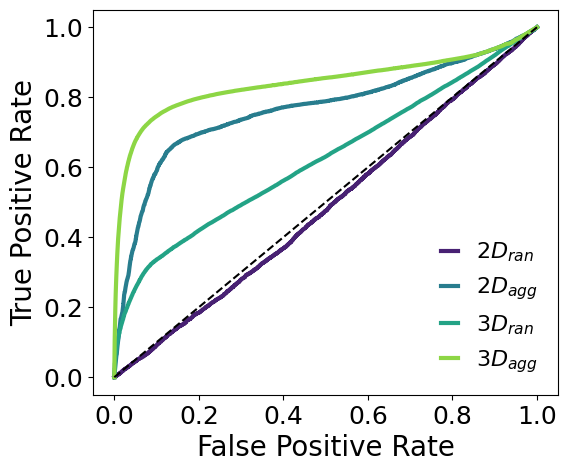

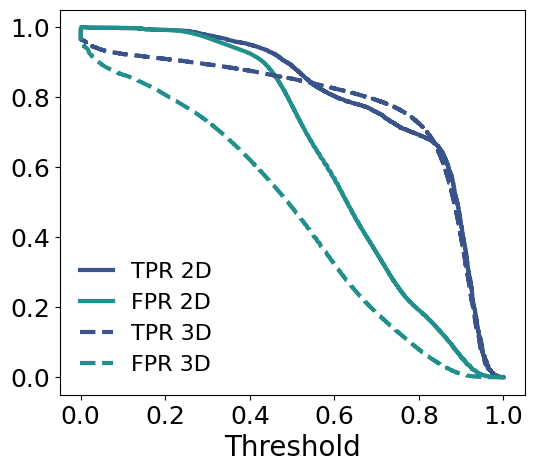

In [ ]:
viridis = load_cmap("viridis", cmap_type="continuous")

plt.figure(figsize=(6, 5))
plt.plot(fpr_2D_1, tpr_2D_1, label=r"$2D_{ran}$", color = viridis(0.), lw = 3)
plt.plot(fpr_2D_2, tpr_2D_2, label=r"$2D_{agg}$", color = viridis(0.4), lw = 3)
plt.plot(fpr_3D_1, tpr_3D_1, label=r"$3D_{ran}$", color = viridis(0.6), lw = 3)
plt.plot(fpr_3D_2, tpr_3D_2, label=r"$3D_{agg}$", color = viridis(0.9), lw = 3)
plt.plot([0, 1], [0, 1], 'k--')
plt.legend(loc='lower right', fontsize = 16, frameon = False, handlelength=0.8)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

plt.figure(figsize=(6, 5))
plt.plot(thresholds_2D_2, tpr_2D_2, color = viridis(0.2), lw = 3, label = "TPR 2D")
plt.plot(thresholds_2D_2, fpr_2D_2, color = viridis(0.5), lw = 3, label = "FPR 2D")
plt.plot(thresholds_3D_2, tpr_3D_2, color = viridis(0.2), lw = 3, ls = "--", label = "TPR 3D")
plt.plot(thresholds_3D_2, fpr_3D_2, color = viridis(0.5), lw = 3, ls = "--", label = "FPR 3D")
# plt.ylabel('False Positive Rate', fontsize = 20)
plt.xlabel('Threshold', fontsize = 20)
plt.legend(loc='best', fontsize = 16, frameon = False, handlelength=1.5)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
# Sacar estas curvas para los axones rectos, mirar el clustering y la global effficiency. Mirar la modularidad y clustering de la estructural y funcional. Para apoyar el resultado de los mapas. Mapa Q_funcional/ Q_estrcutural. Mapa Clustering_funcioanl/Clustering_estructural

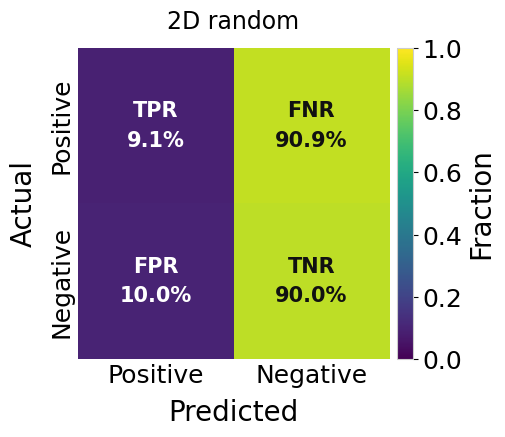

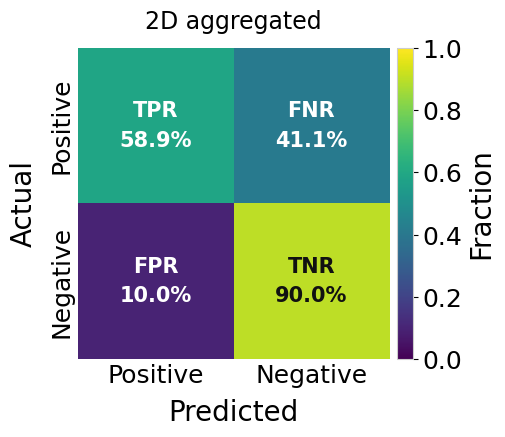

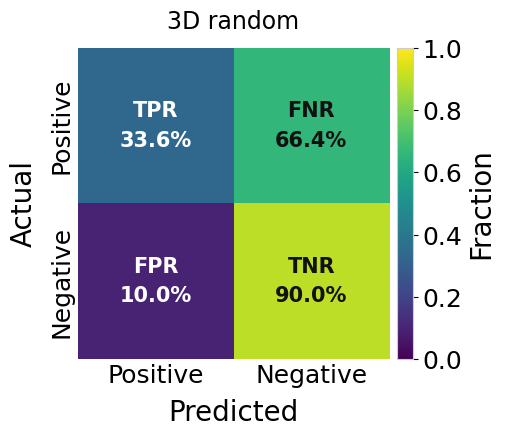

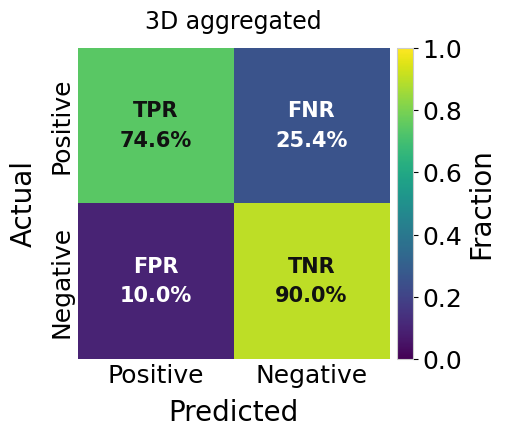

In [99]:
plot_confusion_matrix_normalized(res_2D_1, "2D random")
plot_confusion_matrix_normalized(res_2D_2, "2D aggregated")
plot_confusion_matrix_normalized(res_3D_1, "3D random")
plot_confusion_matrix_normalized(res_3D_2, "3D aggregated")

## Distribution of peaks

In [1]:
sigma_2D_1 = 0.6
exc_weight_2D_1 = 17.5
sigma_2D_2 = 0.04
exc_weight_2D_2 = 15
sigma_3D_1 = 0.6
exc_weight_3D_1 = 17.5
sigma_3D_2 = 0.04
exc_weight_3D_2 = 15

filename_adj_2D_1, filename_dyn_2D_1 = find_filename2D(sigma=sigma_2D_1, exc_weight=exc_weight_2D_1)
filename_adj_2D_2, filename_dyn_2D_2 = find_filename2D(sigma=sigma_2D_2, exc_weight=exc_weight_2D_2)
filename_adj_3D_1, filename_dyn_3D_1 = find_filename3D(sigma=sigma_3D_1, exc_weight=exc_weight_3D_1)
filename_adj_3D_2, filename_dyn_3D_2 = find_filename3D(sigma=sigma_3D_2, exc_weight=exc_weight_3D_2)

A_2D_1 = fcn.load_A(filename_adj_2D_1)
A_2D_1_CG = fcn.get_GC(A_2D_1)
N_2D_1 = A_2D_1.shape[0]

A_2D_2 = fcn.load_A(filename_adj_2D_2)
A_2D_2_CG = fcn.get_GC(A_2D_2)
N_2D_2 = A_2D_2.shape[0]

A_3D_1 = fcn.load_A(filename_adj_3D_1)
A_3D_1_CG = fcn.get_GC(A_3D_1)
N_3D_1 = A_3D_1.shape[0]

A_3D_2 = fcn.load_A(filename_adj_3D_2)
A_3D_2_CG = fcn.get_GC(A_3D_2)
N_3D_2 = A_3D_2.shape[0]

firings_2D_1_t, firings_2D_1_i = fcn.load_firings(filename_dyn_2D_1)
firings_2D_2_t, firings_2D_2_i = fcn.load_firings(filename_dyn_2D_2)
firings_3D_1_t, firings_3D_1_i = fcn.load_firings(filename_dyn_3D_1)
firings_3D_2_t, firings_3D_2_i = fcn.load_firings(filename_dyn_3D_2)
import numpy as np
import matplotlib.pyplot as plt


def get_peak_heights(firings_t, firings_i, N, SIM_TIME=10000, W=25):
    GNA = fcn.compute_GNA_from_raster(
        firings_t=firings_t,
        firings_i=firings_i,
        N=N,
        SIM_TIME=SIM_TIME,
        W=W
    )

    peaks, peak_heights, mean_peaks_height, std_peaks_height = fcn.find_GNA_peaks(GNA)

    return peak_heights, mean_peaks_height, std_peaks_height


peak_heights_2D_1, mean_2D_1, std_2D_1 = get_peak_heights(
    firings_2D_1_t, firings_2D_1_i, N_2D_1,
    SIM_TIME=10000, W=25
)

peak_heights_2D_2, mean_2D_2, std_2D_2 = get_peak_heights(
    firings_2D_2_t, firings_2D_2_i, N_2D_2,
    SIM_TIME=10000, W=25
)

peak_heights_3D_1, mean_3D_1, std_3D_1 = get_peak_heights(
    firings_3D_1_t, firings_3D_1_i, N_3D_1,
    SIM_TIME=10000, W=25
)

peak_heights_3D_2, mean_3D_2, std_3D_2 = get_peak_heights(
    firings_3D_2_t, firings_3D_2_i, N_3D_2,
    SIM_TIME=10000, W=25
)

NameError: name 'find_filename2D' is not defined

In [83]:
def collect_peak_heights_2D(sigma, exc_weight, sims=10, SIM_TIME=10000, W=25):
    all_peak_heights = []

    for sim in range(sims):
        filename_adj, filename_dyn = find_filename2D(
            sigma=sigma,
            exc_weight=exc_weight,
            sim_number=sim
        )

        if not os.path.exists(filename_adj) or not os.path.exists(filename_dyn):
            continue

        A = fcn.load_A(filename_adj)
        N = A.shape[0]

        firings_t, firings_i = fcn.load_firings(filename_dyn)

        peak_heights, _, _ = get_peak_heights(
            firings_t, firings_i, N,
            SIM_TIME=SIM_TIME,
            W=W
        )

        all_peak_heights.extend(peak_heights)

    return np.asarray(all_peak_heights)

def collect_peak_heights_3D(sigma, exc_weight, sims=1, SIM_TIME=10000, W=25):
    all_peak_heights = []

    for sim in range(sims):
        filename_adj, filename_dyn = find_filename3D(
            sigma=sigma,
            exc_weight=exc_weight,
            sim_number=sim
        )

        if not os.path.exists(filename_adj) or not os.path.exists(filename_dyn):
            continue

        A = fcn.load_A(filename_adj)
        N = A.shape[0]

        firings_t, firings_i = fcn.load_firings(filename_dyn)

        peak_heights, _, _ = get_peak_heights(
            firings_t, firings_i, N,
            SIM_TIME=SIM_TIME,
            W=W
        )

        all_peak_heights.extend(peak_heights)

    return np.asarray(all_peak_heights)

peak_heights_2D_1 = collect_peak_heights_2D(
    sigma=sigma_2D_1,
    exc_weight=exc_weight_2D_1,
    sims=10
)

peak_heights_2D_2 = collect_peak_heights_2D(
    sigma=sigma_2D_2,
    exc_weight=exc_weight_2D_2,
    sims=10
)

peak_heights_3D_1 = collect_peak_heights_3D(
    sigma=sigma_3D_1,
    exc_weight=exc_weight_3D_1,
    sims=1
)

peak_heights_3D_2 = collect_peak_heights_3D(
    sigma=sigma_3D_2,
    exc_weight=exc_weight_3D_2,
    sims=1
)

In [84]:
def plot_peak_height_violin_strip(
    peak_heights_list,
    labels,
    positions=None,
    colors=None,
    jitter=0.10,
    figsize=(6, 4.5),
    point_size=16,
    alpha_points=0.45,
    violin_alpha=0.35
):

    rng = np.random.default_rng(123)

    if positions is None:
        positions = np.arange(len(peak_heights_list))

    if colors is None:
        colors = plt.cm.viridis(
            np.linspace(0.15, 0.85, len(peak_heights_list))
        )

    fig, ax = plt.subplots(figsize=figsize)

    # ==========================================================
    # VIOLIN
    # ==========================================================
    vp = ax.violinplot(
        peak_heights_list,
        positions=positions,
        widths=0.22,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for body, color in zip(vp["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor("none")
        body.set_alpha(violin_alpha)
        body.set_zorder(5)
    

    # ==========================================================
    # STRIP
    # ==========================================================

    for i, peak_heights in enumerate(peak_heights_list):

        peak_heights = np.asarray(peak_heights, dtype=float)
        peak_heights = peak_heights[np.isfinite(peak_heights)]

        x0 = positions[i]

        x = x0 + rng.uniform(
            -jitter,
            jitter,
            size=len(peak_heights)
        )

        ax.scatter(
            x,
            peak_heights,
            s=point_size,
            alpha=alpha_points,
            color=colors[i],
            edgecolor="black",
            linewidths=0.1,
            zorder=3,
        )

        mean_val = np.mean(peak_heights)

        ax.hlines(
            mean_val,
            x0 - 0.10,
            x0 + 0.10,
            color="black",
            linewidth=2.0,
            zorder=4
        )

    
    # ==========================================================
    # FORMAT
    # ==========================================================

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=18)

    ax.set_ylabel("GNA peak height", fontsize=20)

    ax.tick_params(labelsize=18)

    ax.set_ylim(0, 1.05)

    fig.tight_layout()

    return fig, ax

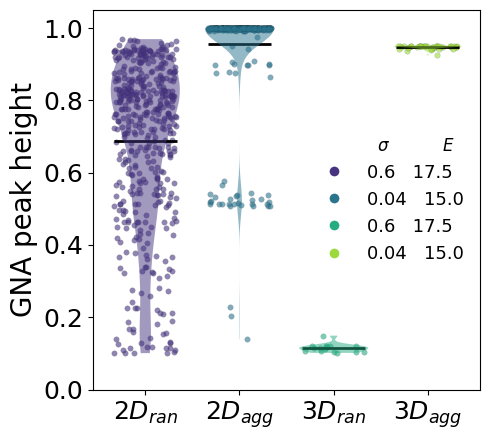

In [85]:
from matplotlib.lines import Line2D

peak_heights_list = [
    peak_heights_2D_1,
    peak_heights_2D_2,
    peak_heights_3D_1,
    peak_heights_3D_2
]

labels = [
    r"$2D_{ran}$",
    r"$2D_{agg}$",
    r"$3D_{ran}$",
    r"$3D_{agg}$"
]

colors = plt.cm.viridis(
    np.linspace(0.15, 0.85, len(peak_heights_list))
)
legend_elements = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[0],
        markersize=8,
        label=f"{sigma_2D_1}   {exc_weight_2D_1:.1f}"
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[1],
        markersize=8,
        label=f"{sigma_2D_2}   {exc_weight_2D_2:.1f}"
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[2],
        markersize=8,
        label=f"{sigma_3D_1}   {exc_weight_3D_1:.1f}"
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[3],
        markersize=8,
        label=f"{sigma_3D_2}   {exc_weight_3D_2:.1f}"
    ),
]

# leg = ax.legend(
#     handles=legend_elements,
#     title=r"         $\sigma \;\;\;\; E$",
#     fontsize=11,
#     title_fontsize=12,
#     frameon=False,
#     loc="lower right",
#     handletextpad=0.8
# )

# ax.legend(
#     handles=legend_elements,
#     fontsize=10,
#     frameon=False,
#     loc="lower right"
# )

positions = [0, 0.3, 0.6, 0.9]

fig, ax = plot_peak_height_violin_strip(
    peak_heights_list,
    labels,
    positions=positions,
    figsize=(5, 4.5),
    jitter=0.10,
    point_size=16,
alpha_points=0.6, 
violin_alpha=0.5
)

plt.legend(
    handles=legend_elements,
    fontsize=13,
    title=r"          $\sigma \;\;\;\;\;\;\;\;\;\;\;\; E$",
    title_fontsize=12,
    frameon=False,
    loc="best"
)

plt.show()

## TPR a FPR 0.1

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

warnings.filterwarnings("ignore", category=RuntimeWarning)

output_filename = "figures_TFM/data_for_figures/3D_roc_tpr_at_fpr0.1_curves_average.txt"

# -----------------------------
# Calcular curvas promediadas
# -----------------------------

target_fpr = 0.1
sims = 1
rows = []

base_sigmas = [0.03, 0.7]
exc_weights = np.linspace(5, 30.0, 50)

rows = []

for base_sigma in base_sigmas:

    print(f"\nProcesando curva: base_sigma={base_sigma:.4f}")

    for exc_weight in exc_weights:

        tpr_values = []
        auc_values = []

        for sim in range(sims):

            filename_adj, filename_dyn = find_filename3D(
                sigma=base_sigma,
                exc_weight=exc_weight,
                sim_number=sim
            )

            if (not os.path.exists(filename_adj)) or (not os.path.exists(filename_dyn)):
                print(f"No existe sim {sim}: sigma={base_sigma:.4f}, E={exc_weight:.3f}")
                continue

            A = fcn.load_A(filename_adj)
            N = A.shape[0]

            F = fcn.build_F_for_roc(
                filename_dyn,
                SIM_TIME=SIM_TIME,
                N=N
            )

            fpr, tpr, roc_auc, _ = compute_roc(A, F)

            order = np.argsort(fpr)
            fpr = fpr[order]
            tpr = tpr[order]

            tpr_at_fpr01 = np.interp(target_fpr, fpr, tpr)

            tpr_values.append(tpr_at_fpr01)
            auc_values.append(roc_auc)

        if len(tpr_values) == 0:
            mean_tpr = np.nan
            std_tpr = np.nan
            mean_auc = np.nan
            std_auc = np.nan
            n_sims = 0
        else:
            mean_tpr = np.mean(tpr_values)
            std_tpr = np.std(tpr_values)
            mean_auc = np.mean(auc_values)
            std_auc = np.std(auc_values)
            n_sims = len(tpr_values)

        rows.append({
            "base_sigma": base_sigma,
            "MAX_EXC_WEIGHT": exc_weight,
            "tpr_at_fpr0.1_mean": mean_tpr,
            "tpr_at_fpr0.1_std": std_tpr,
            "auc_mean": mean_auc,
            "auc_std": std_auc,
            "n_sims": n_sims
        })

df_out = pd.DataFrame(rows)
df_out.to_csv(output_filename, sep="\t", index=False)

print(f"\nGuardado en: {output_filename}")


Procesando curva: base_sigma=0.0300


In [ ]:
output_filename2D = "figures_TFM/data_for_figures/2D_roc_tpr_at_fpr0.1_curves_average.txt"
output_filename3D = "figures_TFM/data_for_figures/3D_roc_tpr_at_fpr0.1_curves_average.txt"
df2D = pd.read_csv(output_filename2D, sep="\t")
df3D = pd.read_csv(output_filename3D, sep="\t")

plt.figure(figsize=(6, 5))

viridis = load_cmap("viridis", cmap_type="continuous")

colors = [viridis(0.0), viridis(0.4), viridis(0.6), viridis(0.9)]
labels2D = [r"$2D_{ran}$", r"$2D_{agg}$"]
labels3D = [r"$3D_{ran}$", r"$3D_{agg}$"]
k = 0
for (gini, base_sigma), group in df2D.groupby(["Gini", "base_sigma"]):

    group = group.sort_values("MAX_EXC_WEIGHT")

    x = group["MAX_EXC_WEIGHT"].to_numpy()
    y = group["tpr_at_fpr0.1_mean"].to_numpy()
    yerr = group["tpr_at_fpr0.1_std"].to_numpy()

    plt.plot(
        x, y,
        "-",
        lw = 3,
        label=labels2D[k], 
        color=colors[k]
    )

    plt.fill_between(
        x,
        y - yerr,
        y + yerr,
        alpha=0.2, 
        color = colors[k]
    )
    k +=1

k = 0
c = 0
for (gini, base_sigma), group in df3D.groupby(["Gini", "base_sigma"]):

    group = group.sort_values("MAX_EXC_WEIGHT")

    x = group["MAX_EXC_WEIGHT"].to_numpy()
    y = group["tpr_at_fpr0.1_mean"].to_numpy()
    yerr = group["tpr_at_fpr0.1_std"].to_numpy()

    plt.plot(
        x, y,
        "--",
        lw = 3,
        label=labels3D[k], 
        color=colors[k]
    )

    # plt.fill_between(
    #     x,
    #     y - yerr,
    #     y + yerr,
    #     alpha=0.2, 
    #     color = colors[k]
    # )
    k +=1
    c+=1

plt.xlabel("E", fontsize = 20)
plt.ylabel(r"TPR at FPR = 0.1", fontsize = 20)
plt.xticks([2, 5, 10, 15, 20], fontsize = 18)
plt.yticks(fontsize = 18)
plt.legend(fontsize = 14, frameon = False, handlelength=1.5)
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Map of modularity and clustering

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
from pypalettes import load_cmap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

from matplotlib.ticker import FuncFormatter


def find_filename2D(parameters2D = None, sigma = 0.5, exc_weight = 8.5, sim_number = 0):

    if parameters2D is None:
        parameters2D = {
            "L": 2.0,
            "rho": 125,
            "soma_diameter": 0.015,
            "d_mean": 0.15,
            "d_sigma": 0.02,
            "l_mean": 1.00,
            "segment_length": 0.01,
            "sigma_axon_angle": 0.1,
            "agg": 1,
            "n_centers": 10,
            "base_sigma": 0.5,
            "BC_type": "SW",
            "geometry": "squareLongRange"   # "square" or "circle"
    }

    parametersDynamics = {
        "max_exc_weight": 8.5,
        "max_inh_weight": 0.5,
        "noise_max": 3,
        "sim_time": 10000,
        "seed": 42
    }

    alpha = 0.1
    sim = sim_number

    calibration_filename = "figures_TFM/data_for_figures/gini2D_n_grid13_calibration.txt"
    data = np.loadtxt(calibration_filename, skiprows=1)
    base_sigma_values = data[:,1]

    # base_sigma_values = np.linspace(0.04, 0.6, 50)
    MAX_EXC_WEIGHT_values = np.linspace(2, 20.0, 50)


    base_sigma_target = sigma
    MAX_EXC_WEIGHT_target = exc_weight

    base_sigma = base_sigma_values[np.abs(base_sigma_values - base_sigma_target).argmin()]
    MAX_EXC_WEIGHT = MAX_EXC_WEIGHT_values[np.abs(MAX_EXC_WEIGHT_values - MAX_EXC_WEIGHT_target).argmin()]


    # ============================================================
    # FILENAMES
    # ============================================================


    filename_adj_2D = (
        f"2D_dynamics/networks_for_dynamics/"
        f"2D_adjacency_matrix_{parameters2D['geometry']}_{parameters2D['BC_type']}"
        f"_agg_nc{parameters2D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}"
        f"_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}"
        f"_a{alpha:.2f}_sim{sim}.txt"
    )

    filename_dyn_2D = (
        f"2D_dynamics/2D_dynamics_{parameters2D['geometry']}_{parameters2D['BC_type']}"
        f"_agg_nc{parameters2D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}"
        f"_a{alpha:.2f}_exc{MAX_EXC_WEIGHT:.3f}_sim{sim}.txt"
    )

    if not os.path.exists(filename_adj_2D):
        print(f"Archivo no encontrado: {filename_adj_2D}")
    if not os.path.exists(filename_dyn_2D):
        print(f"Archivo no encontrado: {filename_dyn_2D}")
        
    return filename_adj_2D, filename_dyn_2D

def find_filename3D(parameters3D = None, sigma = 0.04, exc_weight = 8.5, sim_number = 0):

    if parameters3D is None:
        parameters3D = {
            "L": 2.0, # Length of the square domain (mm) or diameter of the circular domain (mm)
            "height": 1.0, # Height of the cylinder domain (mm), only used if geometry is "cylinder"
            "rho": 1400, # Neuron density (neurons/mm^2)
            "soma_diameter": 0.015, # Diameter of the soma (mm)
            "d_mean": 0.15, # Dendritic tree diameter (mm) Gaussian distribution
            "d_sigma": 0.02, # Standard deviation of the dendritic tree diameter (mm)
            "l_mean": 1.00, # Mean axon length (mm) Rayleigh distribution
            "segment_length": 0.01, # Segment length for axon growth (mm)
            "sigma_pol": 0.1, # Standard deviation of the axon angle (radians)
            "sigma_azi": 0.1, # Standard deviation of the azimuthal angle (radians)
            "agg": 1, # Control parameter for the aggregation of neurons
            "n_centers": 112, # Number of centers for the aggregation of neurons
            "base_sigma": 0.04, # Base standard deviation for aggregation centers (mm)
            "BC_type": "SW",  # Boundary conditions type (PBC: Periodic Boundary Conditions, SW: Sticky Walls)
            "geometry": "cube", # Geometry of the domain (cube or sphere)
            "seed": 0,
    }

    parametersDynamics = {
        "max_exc_weight": 8.5,
        "max_inh_weight": 0.5,
        "noise_max": 3,
        "sim_time": 10000,
        "seed": 42
    }

    alpha = 0.1
    sim = sim_number

    calibration_filename = "figures_TFM/data_for_figures/gini3D_n_grid13_calibration.txt"
    data = np.loadtxt(calibration_filename, skiprows=1)
    base_sigma_values = data[:,1]

    # base_sigma_values = np.linspace(0.04, 0.6, 50)
    MAX_EXC_WEIGHT_values = np.linspace(2, 20.0, 50)


    base_sigma_target = sigma
    MAX_EXC_WEIGHT_target = exc_weight

    base_sigma = base_sigma_values[np.abs(base_sigma_values - base_sigma_target).argmin()]
    MAX_EXC_WEIGHT = MAX_EXC_WEIGHT_values[np.abs(MAX_EXC_WEIGHT_values - MAX_EXC_WEIGHT_target).argmin()]

    sunset2 = load_cmap("Sunset2", cmap_type="continuous")

    # ============================================================
    # FILENAMES
    # ============================================================

    filename_adj_3D = (
        f"3D_dynamics/networks_for_dynamics/"
        f"3D_adjacency_matrix_{parameters3D['geometry']}_{parameters3D['BC_type']}"
        f"_agg_nc{parameters3D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters3D['L']:.1f}_h{parameters3D['height']:.2f}_rho{parameters3D['rho']:.0f}"
        f"_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}"
        f"_a{alpha:.2f}_sim{sim}.txt"
    )

    filename_dyn_3D = (
        f"3D_dynamics/3D_dynamics_{parameters3D['geometry']}_{parameters3D['BC_type']}"
        f"_agg_nc{parameters3D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters3D['L']:.1f}_h{parameters3D['height']:.2f}_rho{parameters3D['rho']:.0f}"
        f"_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}"
        f"_a{alpha:.2f}_exc{MAX_EXC_WEIGHT:.3f}_sim{sim}.txt"
    )

    if not os.path.exists(filename_adj_3D):
        print(f"Archivo no encontrado: {filename_adj_3D}")
    if not os.path.exists(filename_dyn_3D):
        print(f"Archivo no encontrado: {filename_dyn_3D}")
    return filename_adj_3D, filename_dyn_3D

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

calibration_filename = "figures_TFM/data_for_figures/gini2D_n_grid13_calibration.txt"
data = np.loadtxt(calibration_filename, skiprows=1)
gini_values = data[:,0]
base_sigma_values = data[:,1]

MAX_EXC_WEIGHT_values = np.linspace(2, 20.0, 50)

def louvain_modularity(A):
    import networkx as nx

    G = nx.from_numpy_array(A)

    if G.number_of_edges() == 0:
        return np.nan

    communities = nx.community.louvain_communities(G, seed=0)
    modularity = nx.community.modularity(G, communities)

    return modularity
def compute_clustering_coefficient(A):
    import networkx as nx

    G = nx.from_numpy_array(A)

    if G.number_of_edges() == 0:
        return np.nan

    clustering_coeffs = nx.clustering(G)
    average_clustering = np.mean(list(clustering_coeffs.values()))

    return average_clustering

sims = 10
for sim in range(sims):
    out_filename_modularity = f"figures_TFM/data_for_figures/modularity_map_2D_sim_{sim}.txt"
    out_filename_clustering = f"figures_TFM/data_for_figures/clustering_map_2D_sim_{sim}.txt"
    k = 0
    with open(out_filename_modularity, "w") as f:
        f.write("sigma\tgini\texc_weight\tmodF\tmodA\tmodF/modA\n")
    with open(out_filename_clustering, "w") as f:
        f.write("sigma\tgini\texc_weight\tclusF\tclusA\tclusF/clusA\n")
    for sigma in base_sigma_values:
        gini = gini_values[k]
        filename_adj_2D, _= find_filename2D(sigma=sigma, exc_weight=MAX_EXC_WEIGHT_values[0], sim_number=sim)
        if not os.path.exists(filename_adj_2D):
            print(f"Archivo no encontrado para sigma={sigma:.4f}")
            continue
        A_2D = fcn.load_A(filename_adj_2D)
        A_2D = ((A_2D + A_2D.T) > 0).astype(int)  # Ensure the adjacency matrix is symmetric and binary
        modularity_2D = louvain_modularity(A_2D)
        clustering_2D = compute_clustering_coefficient(A_2D)
        for exc_weight in MAX_EXC_WEIGHT_values:

            _, filename_dyn_2D = find_filename2D(sigma=sigma, exc_weight=exc_weight, sim_number=sim)
            if not os.path.exists(filename_dyn_2D):
                print(f"Archivo no encontrado para sigma={sigma:.4f}, exc_weight={exc_weight:.1f}")
                continue

            F, F_binary, F_ordered, order, communities = fcn.build_F_matrix(filename_dyn_2D, SIM_TIME = 10000, N = A_2D.shape[0])
            F_binary = ((F_binary + F_binary.T) > 0).astype(int)  # Ensure the functional connectivity matrix is symmetric and binary
            modularity_F_2D = louvain_modularity(F_binary)
            clustering_F_2D = compute_clustering_coefficient(F_binary)
            modularity_ratio_2D = modularity_F_2D / modularity_2D if modularity_2D != 0 else np.nan

            print(f"Sigma: {sigma:.4f}, Gini: {gini:.4f}, Exc Weight: {exc_weight:.1f}, Modularity F 2D: {modularity_F_2D:.4f}, Modularity A 2D: {modularity_2D:.4f}, Ratio: {modularity_ratio_2D:.4f}")
            print(f"Sigma: {sigma:.4f}, Gini: {gini:.4f}, Exc Weight: {exc_weight:.1f}, Clustering F 2D: {clustering_F_2D:.4f}, Clustering A 2D: {clustering_2D:.4f}, Ratio: {clustering_F_2D/clustering_2D:.4f}")
            with open(out_filename_modularity, "a") as f:
                f.write(f"{sigma:.4f}\t{gini:.4f}\t{exc_weight:.1f}\t{modularity_F_2D:.4f}\t{modularity_2D:.4f}\t{modularity_ratio_2D:.4f}\n")
            with open(out_filename_clustering, "a") as f:
                f.write(f"{sigma:.4f}\t{gini:.4f}\t{exc_weight:.1f}\t{clustering_F_2D:.4f}\t{clustering_2D:.4f}\t{clustering_F_2D/clustering_2D:.4f}\n")
        k += 1

In [ ]:
import pandas as pd
from functools import reduce

# =========================
# LIST OF FILES
# =========================

sims = 7
filenames = [f"figures_TFM/data_for_figures/clustering_map_2D_sim_{i}.txt" for i in range(sims)]

# =========================
# LOAD ALL FILES
# =========================

dfs = [pd.read_csv(f, sep=r"\s+") for f in filenames]

# =========================
# COLUMNS THAT IDENTIFY EACH POINT
# =========================

keys = ["sigma", "gini", "exc_weight"]

# =========================
# NUMERICAL COLUMNS TO AVERAGE
# =========================

value_columns = [col for col in dfs[0].columns if col not in keys]

# =========================
# MERGE ALL DATAFRAMES
# =========================

merged = dfs[0]

for i, df in enumerate(dfs[1:], start=1):

    renamed = df.rename(
        columns={
            col: f"{col}_{i}"
            for col in value_columns
        }
    )

    merged = pd.merge(
        merged,
        renamed,
        on=keys
    )

# =========================
# COMPUTE MEANS
# =========================

result = merged[keys].copy()

for col in value_columns:

    cols_to_average = [col] + [f"{col}_{i}" for i in range(1, len(dfs))]

    result[col] = merged[cols_to_average].mean(axis=1)

# =========================
# SAVE OUTPUT
# =========================

output_filename = "figures_TFM/data_for_figures/clustering_map_2D_average.txt"

result.to_csv(
    output_filename,
    sep="\t",
    index=False,
    float_format="%.4f"
)

print(f"Saved averaged file to: {output_filename}")